# EDA — Panel JLoss × GaR × EMBI (base final Bloomberg)

Análisis exploratorio sobre la **base final ancla en Bloomberg** (`bbg/Panel_bloomberg.csv`, 13-14 economías emergentes, EMBI Global Diversified) — la misma base sobre la que corren la batería de 24 regresiones (Tabla 2.3 de la tesis) y toda la robustez del Capítulo 2. Reemplaza la versión anterior de este notebook, que corría sobre la base regulatoria superada `Panel_extended_15paises.csv` (11 países, sin EMBI Global Diversified). La celda de configuración define qué CSV se lee; el resto auto-detecta las columnas disponibles (controles domésticos, VIX) y ajusta las grillas al número de países. Secciones **1–12** (exploratorio), **13** (forma de la distribución del GaR) y **14** (figuras de resultados basadas en las regresiones). *Run All* en orden.

Requisitos: `pip install pandas numpy matplotlib seaborn scipy statsmodels linearmodels`.


In [1]:
# === CONFIGURACIÓN — base final Bloomberg: 13-14 países con EMBI Global Diversified ===
INFILE      = 'bbg/Panel_bloomberg.csv'
OUTDIR_NAME = 'eda_output_bbg'


In [2]:
import numpy as np, pandas as pd, math, os, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

OUTDIR = Path(OUTDIR_NAME); OUTDIR.mkdir(exist_ok=True)
FIGDIR = OUTDIR / 'figuras'; FIGDIR.mkdir(exist_ok=True)
def savefig(name): plt.savefig(FIGDIR / f'{name}.png', dpi=140, bbox_inches='tight')
def grid(n, ncols=None):
    if ncols is None: ncols = 3 if n <= 6 else 4
    return math.ceil(n / ncols), ncols
print('Salida ->', OUTDIR.resolve())

Salida -> C:\Users\HOME\Claude\proyects\Jloss\1_Codigo\Panel\eda_output_bbg


## 1. Carga, preparación y detección de columnas

In [3]:
df = pd.read_csv(INFILE)
df['country'] = df['country'].str.lower()
df['t']    = pd.PeriodIndex(df['quarter'], freq='Q')
df['date'] = df['t'].dt.to_timestamp()
df['year'] = df['t'].dt.year
df = df.sort_values(['country', 't']).reset_index(drop=True)

LABELS = {
 'EMBI_bps':'Spread EMBI (pb)', 'JLoss':'Fragilidad bancaria JLoss',
 'GaR':'Growth-at-Risk (q05)', 'GaR_st':'GaR skew-t', 'ES':'Expected Shortfall',
 'prob_neg':'Prob. crecim. negativo', 'skew':'Asimetría', 'std':'Desv. condicional',
 'VIX':'VIX', 'VIX_cboe':'VIX (CBOE)', 'g_GDP':'Crecimiento PIB',
 'debt_gdp':'Deuda/PIB (%)', 'fisc_bal':'Balance fiscal/PIB (%)',
 'res_gdp':'Reservas/PIB (%)', 'ca_gdp':'Cuenta corriente/PIB (%)',
 'infl_yoy':'Inflación YoY (%)', 'reer':'REER (índice)', 'JLoss_x_GaR':'JLoss × GaR',
 'X_dom_idx':'Índice doméstico', 'X_global_idx':'Índice global'}

def present(cols):
    return [c for c in cols if c in df.columns and df[c].notna().sum() > 0]

CORE   = present(['EMBI_bps','JLoss','GaR','ES','prob_neg'])
CTRLS  = present(['debt_gdp','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer'])
VIXVAR = 'VIX' if 'VIX' in df.columns else ('VIX_cboe' if 'VIX_cboe' in df.columns else None)
ALLV   = list(dict.fromkeys(CORE + present(['GaR_st','skew','std','g_GDP']) + CTRLS + ([VIXVAR] if VIXVAR else [])))

print('Dimensiones:', df.shape)
print('CORE  :', CORE)
print('CTRLS :', CTRLS if CTRLS else '(sin controles domésticos en esta base)')
print('VIX   :', VIXVAR)
df.head()

Dimensiones: (1488, 40)
CORE  : ['EMBI_bps', 'JLoss', 'GaR', 'ES', 'prob_neg']
CTRLS : ['debt_gdp', 'fisc_bal', 'res_gdp', 'ca_gdp', 'infl_yoy', 'reer']
VIX   : VIX


,country,quarter,JLoss,n_banks,below_min_banks,GaR,ES,prob_neg,skew,std,...,infl_yoy,reer,HHI_struct,GaR_pp,JLoss_x_GaR,USD_NEER,USD_NEER_log,t,date,year
0,argentina,2004Q1,4.7752,3,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.4307,NaN,NaN,89.5900,4.4952,2004Q1,2004-01-01,2004
1,argentina,2004Q2,7.8826,3,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.4307,NaN,NaN,91.6833,4.5183,2004Q2,2004-04-01,2004
2,argentina,2004Q3,2.8004,3,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.4307,NaN,NaN,90.9267,4.5101,2004Q3,2004-07-01,2004
3,argentina,2004Q4,3.8562,3,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.4307,NaN,NaN,87.4900,4.4715,2004Q4,2004-10-01,2004
4,argentina,2005Q1,3.4446,3,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.4307,NaN,NaN,86.4000,4.4590,2005Q1,2005-01-01,2005


## 2. Cobertura del panel

In [4]:
n_country = df['country'].nunique(); n_periods = df['t'].nunique()
print(f'Países: {n_country} | Trimestres distintos: {n_periods} | Observaciones: {len(df)}')
print(f'Balance teórico: {n_country*n_periods} | balance real: {len(df)/(n_country*n_periods):.1%}')
cov = (df.groupby('country')
         .agg(N=('quarter','size'), inicio=('quarter','min'), fin=('quarter','max'))
         .reset_index())
cov.to_csv(OUTDIR/'cobertura_por_pais.csv', index=False)
cov

Países: 17 | Trimestres distintos: 91 | Observaciones: 1488
Balance teórico: 1547 | balance real: 96.2%


,country,N,inicio,fin
0,argentina,91,2004Q1,2026Q3
1,brazil,91,2004Q1,2026Q3
2,chile,91,2004Q1,2026Q3
3,china,81,2006Q3,2026Q3
4,colombia,87,2005Q1,2026Q3
5,egypt,90,2004Q2,2026Q3
6,india,78,2007Q2,2026Q3
7,indonesia,91,2004Q1,2026Q3
8,malaysia,91,2004Q1,2026Q3
9,mexico,91,2004Q1,2026Q3


### 2.1 Por qué algunos países no aportan a la muestra de estimación

El roster de arriba (17 países) es todo país con `JLoss` calculable. Pero `EMBI_bps` y `GaR` no están disponibles para todos: la muestra de estimación (la que corren la batería de regresiones y el artifact) es la intersección **EMBI + JLoss + GaR**, que son 13 países. Argentina, Egipto y Rusia tienen `JLoss` pero **cero** trimestres de `GaR` (el motor nunca les generó serie) y tampoco tienen EMBI Global Diversified de Bloomberg; Pakistán tiene algo de `GaR` pero tampoco EMBI. Esto es así **desde el pipeline mismo** — no es un faltante de esta corrida — y es el mismo panel y el mismo núcleo de 13 países que sostiene `resumen_bloomberg.html` y la Tabla 2.3 de la tesis. Fuente: `bbg/cobertura_panel_bbg.csv` (generado por `p1_build_panels.py`).


In [5]:
cob_bbg_path = Path('bbg/cobertura_panel_bbg.csv')
if cob_bbg_path.exists():
    cob_bbg = pd.read_csv(cob_bbg_path)
    display_cols = ['country','jloss_q','gar_q','embi_q','cds_q','embi_cobertura','n_estimacion','ventana_est']
    print('Motivo de exclusión de la muestra de estimación (embi_cobertura=="sin serie"):')
    print(cob_bbg.loc[cob_bbg.embi_cobertura=='sin serie', display_cols].to_string(index=False))
    print()
    print(f"Muestra de estimación (EMBI+JLoss+GaR): {(cob_bbg['n_estimacion']>0).sum()} países, "
          f"{cob_bbg['n_estimacion'].sum()} obs.")
    cob_bbg[display_cols]
else:
    print('bbg/cobertura_panel_bbg.csv no encontrado -- solo aplica a la base Bloomberg.')


Motivo de exclusión de la muestra de estimación (embi_cobertura=="sin serie"):
  country  jloss_q  gar_q  embi_q  cds_q embi_cobertura  n_estimacion ventana_est
argentina       91      0       0     78      sin serie             0           -
    egypt       90      0       0     26      sin serie             0           -
 pakistan       82     38       0      7      sin serie             0           -
   russia       69     44       0     14      sin serie             0           -

Muestra de estimación (EMBI+JLoss+GaR): 13 países, 721 obs.


## 3. Datos faltantes

In [6]:
miss = (df[ALLV].isna().mean()*100).round(1).sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    print('Columnas con faltantes (%):'); print(miss.to_string())
else:
    print('Sin faltantes en las variables analizadas.')

Columnas con faltantes (%):


EMBI_bps   39.5000
GaR        28.8000
ES         28.8000
GaR_st     28.8000
prob_neg   28.8000
skew       28.8000
std        28.8000
infl_yoy   27.1000
ca_gdp     25.7000
res_gdp    25.1000
reer       23.9000
fisc_bal   23.3000
debt_gdp   23.3000


## 4. Estadística descriptiva

In [7]:
def describe_block(d, cols):
    s = d[cols].describe(percentiles=[.25,.5,.75]).T
    s = s[['count','mean','std','min','25%','50%','75%','max']]
    s.columns = ['N','Media','Desv.','Mín','p25','Mediana','p75','Máx']
    s.index = [LABELS.get(c,c) for c in cols]
    return s.round(3)

desc_cols = CORE + present(['skew','std','g_GDP']) + CTRLS + ([VIXVAR] if VIXVAR else [])
desc = describe_block(df, desc_cols)
desc.to_csv(OUTDIR/'tabla_descriptiva_global.csv')

def to_latex_booktabs(d, caption, label):   # sin depender de jinja2 (portable)
    esc = lambda s: str(s).replace('_','\\_').replace('%','\\%').replace('&','\\&')
    cols = list(d.columns)
    out  = ['\\begin{table}[htbp]','\\centering', f'\\caption{{{caption}}}', f'\\label{{{label}}}',
            '\\begin{tabular}{l' + 'r'*len(cols) + '}', '\\toprule',
            ' & '.join([''] + [esc(c) for c in cols]) + ' \\\\', '\\midrule']
    for idx, row in d.iterrows():
        vals = [f'{v:.3f}' if isinstance(v,(int,float,np.floating)) else esc(v) for v in row]
        out.append(' & '.join([esc(idx)] + vals) + ' \\\\')
    out += ['\\bottomrule','\\end{tabular}','\\end{table}','']
    return '\n'.join(out)

with open(OUTDIR/'tabla_descriptiva_global.tex','w') as f:
    f.write(to_latex_booktabs(desc, f'Estadistica descriptiva del panel ({df.quarter.min()}--{df.quarter.max()}).','tab:desc'))
desc

,N,Media,Desv.,Mín,p25,Mediana,p75,Máx
Spread EMBI (pb),900.0000,197.3990,107.4350,15.0000,126.8500,175.5110,246.5630,660.5870
Fragilidad bancaria JLoss,"1,488.0000",4.6830,4.6400,1.4340,2.2250,2.7210,4.7780,31.8860
Growth-at-Risk (q05),"1,059.0000",0.0160,0.0380,-0.2090,-0.0040,0.0180,0.0410,0.1330
Expected Shortfall,"1,059.0000",0.0060,0.0400,-0.2150,-0.0150,0.0090,0.0340,0.1190
Prob. crecim. negativo,"1,059.0000",0.0950,0.2130,0.0000,0.0000,0.0000,0.0710,1.0000
Asimetría,"1,059.0000",-0.0010,0.1850,-0.8650,-0.0780,0.0060,0.0800,0.5860
Desv. condicional,"1,059.0000",0.0130,0.0030,0.0030,0.0110,0.0120,0.0140,0.0250
Deuda/PIB (%),"1,141.0000",47.8530,20.6490,6.5000,32.1750,46.1840,62.8600,106.9000
Balance fiscal/PIB (%),"1,141.0000",-3.4660,2.6840,-13.2000,-5.2000,-3.3000,-1.7000,6.1500
Reservas/PIB (%),"1,114.0000",19.6420,10.0250,2.6480,12.5740,16.3460,25.6720,53.2220


In [8]:
by_country = (df.groupby('country')[CORE].agg(['mean','std']).round(3))
by_country.columns = [f'{LABELS.get(v,v)} ({s})' for v,s in by_country.columns]
by_country.to_csv(OUTDIR/'tabla_descriptiva_por_pais.csv')
by_country.T

country,argentina,brazil,chile,china,colombia,egypt,india,indonesia,malaysia,mexico,pakistan,peru,philippines,poland,russia,southafrica,turkey
Spread EMBI (pb) (mean),NaN,271.5210,141.4780,149.4640,243.7010,NaN,153.2300,94.1740,132.6490,258.3090,NaN,188.1730,75.4950,99.8500,NaN,285.1250,335.0210
Spread EMBI (pb) (std),NaN,96.2760,50.9020,53.3440,86.3720,NaN,53.1670,11.6850,58.6510,96.6680,NaN,69.2280,9.1060,62.2890,NaN,55.0700,120.1710
Fragilidad bancaria JLoss (mean),5.1480,4.6760,3.0920,6.8910,3.9400,2.5720,7.7020,3.0630,2.4920,3.1400,9.5240,2.5750,3.0250,3.8820,8.5730,3.2790,8.0710
Fragilidad bancaria JLoss (std),3.4240,2.8160,2.0390,6.6620,2.9070,1.1240,4.8800,1.9030,0.9080,2.1690,8.3380,1.1160,1.5100,2.8880,7.2420,2.4460,7.0070
Growth-at-Risk (q05) (mean),NaN,-0.0040,0.0030,0.0560,0.0040,NaN,0.0420,0.0230,0.0150,-0.0130,0.0030,0.0180,0.0250,0.0110,0.0200,-0.0050,0.0340
Growth-at-Risk (q05) (std),NaN,0.0320,0.0310,0.0320,0.0350,NaN,0.0330,0.0340,0.0340,0.0320,0.0360,0.0340,0.0300,0.0310,0.0350,0.0390,0.0330
Expected Shortfall (mean),NaN,-0.0130,-0.0060,0.0490,-0.0050,NaN,0.0330,0.0150,0.0000,-0.0220,-0.0110,0.0080,0.0160,0.0030,0.0080,-0.0130,0.0240
Expected Shortfall (std),NaN,0.0350,0.0330,0.0350,0.0360,NaN,0.0350,0.0370,0.0350,0.0330,0.0370,0.0370,0.0330,0.0320,0.0400,0.0410,0.0370
Prob. crecim. negativo (mean),NaN,0.1850,0.1060,0.0150,0.1080,NaN,0.0240,0.0570,0.0970,0.1970,0.1240,0.0500,0.0510,0.0960,0.0650,0.2060,0.0290
Prob. crecim. negativo (std),NaN,0.2780,0.2070,0.0990,0.2250,NaN,0.1240,0.2070,0.2210,0.2740,0.2250,0.1510,0.1780,0.2160,0.1390,0.2700,0.1080


## 5. Distribuciones, asimetría y colas

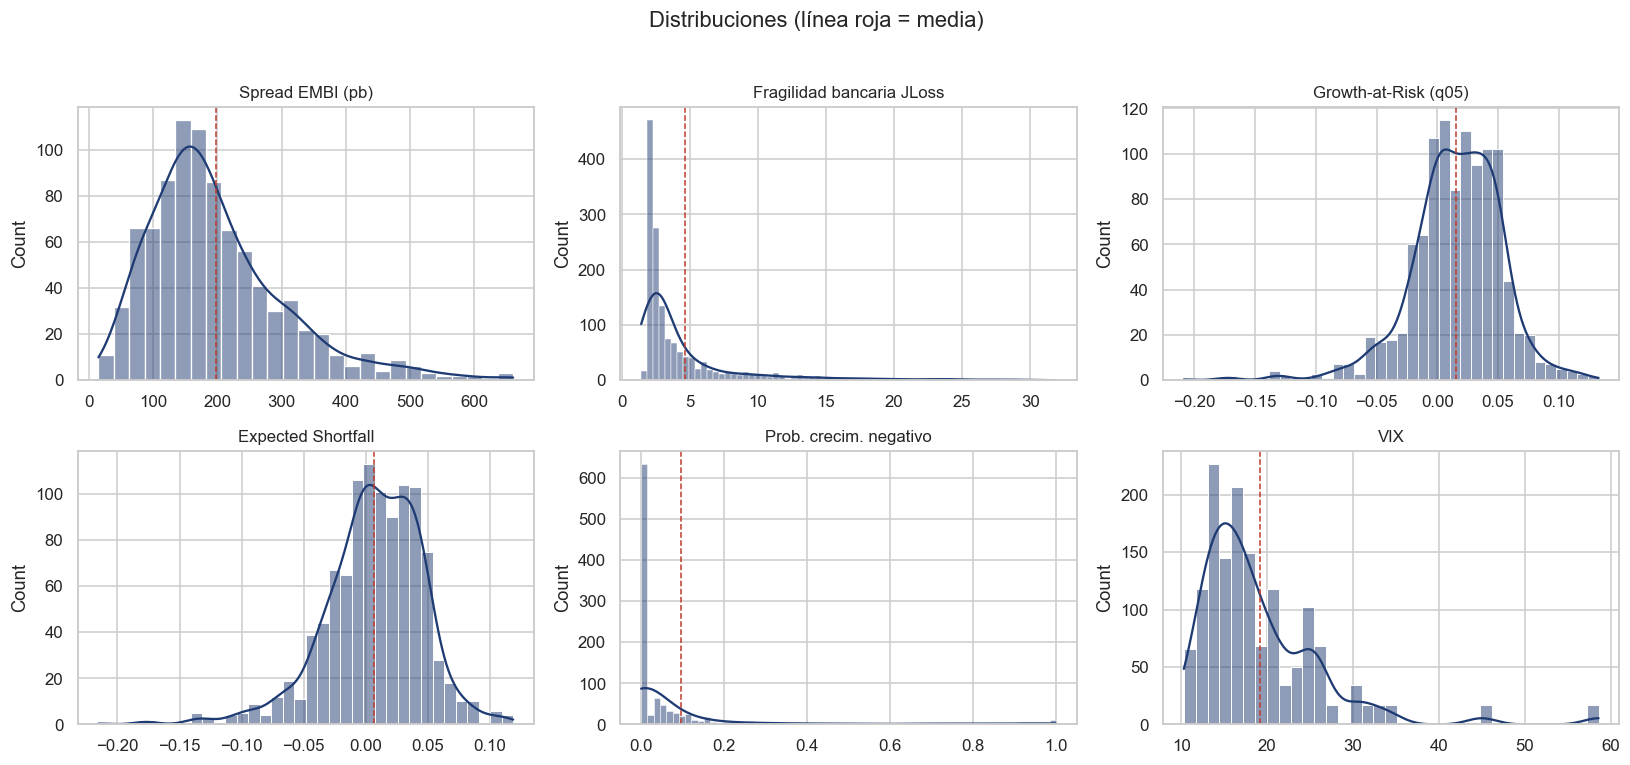

                           Asimetría  Curtosis
Spread EMBI (pb)              1.2600    2.0300
Fragilidad bancaria JLoss     2.8700    8.9300
Growth-at-Risk (q05)         -0.9300    3.5300
Expected Shortfall           -0.8800    2.5300
Prob. crecim. negativo        2.9000    7.7500
VIX                           2.4200    8.7600


In [9]:
from scipy.stats import skew as sk, kurtosis as ku
vars_dist = present(['EMBI_bps','JLoss','GaR','ES','prob_neg']) + ([VIXVAR] if VIXVAR else [])
n = len(vars_dist); nr, nc = grid(n)
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 3.4*nr)); axes = np.atleast_1d(axes).ravel()
for i,v in enumerate(vars_dist):
    sns.histplot(df[v].dropna(), kde=True, ax=axes[i], color='#1f3b73')
    axes[i].set_title(LABELS.get(v,v)); axes[i].set_xlabel('')
    axes[i].axvline(df[v].mean(), color='#c0392b', ls='--', lw=1)
for j in range(n, len(axes)): axes[j].axis('off')
fig.suptitle('Distribuciones (línea roja = media)', y=1.02)
plt.tight_layout(); savefig('04_distribuciones'); plt.show()
shape = pd.DataFrame({'Asimetría':[sk(df[v].dropna()) for v in vars_dist],
                      'Curtosis':[ku(df[v].dropna()) for v in vars_dist]},
                     index=[LABELS.get(v,v) for v in vars_dist]).round(2)
print(shape.to_string())

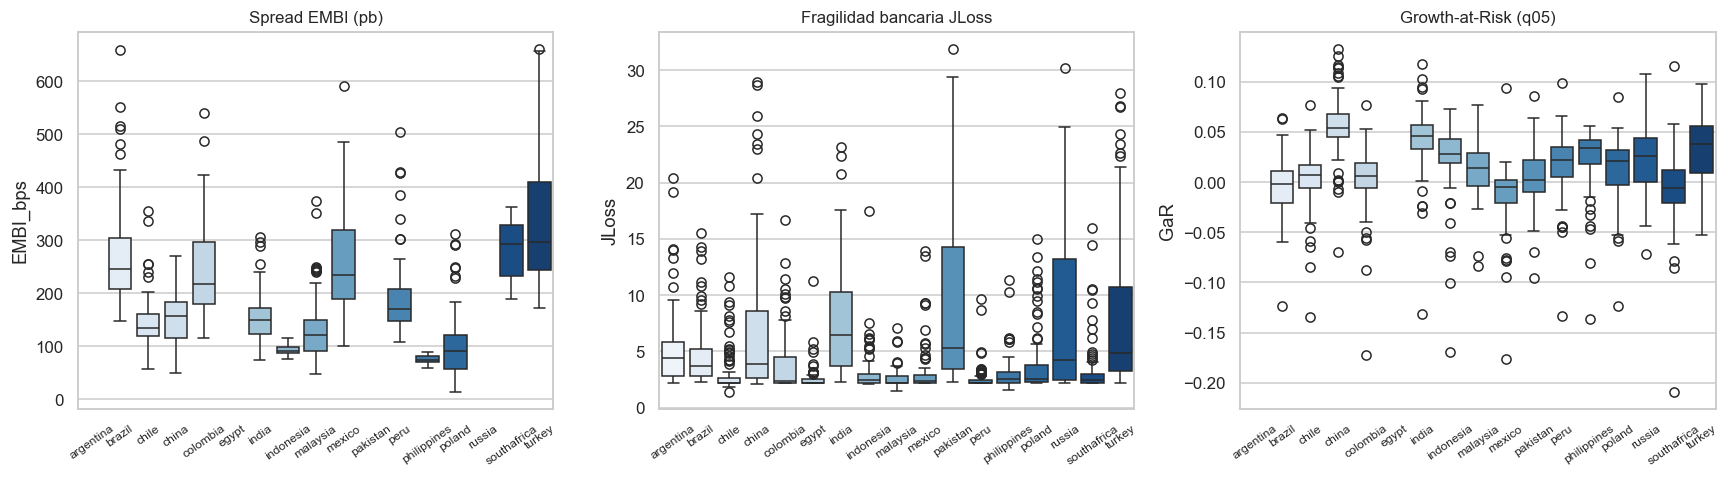

In [10]:
bvars = present(['EMBI_bps','JLoss','GaR'])
fig, axes = plt.subplots(1, len(bvars), figsize=(5.3*len(bvars), 4.5)); axes = np.atleast_1d(axes)
for ax,v in zip(axes, bvars):
    sns.boxplot(data=df, x='country', y=v, hue='country', legend=False, ax=ax, palette='Blues')
    ax.set_title(LABELS.get(v,v)); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35, labelsize=8)
plt.tight_layout(); savefig('04b_boxplots_pais'); plt.show()

## 6. Series de tiempo por país

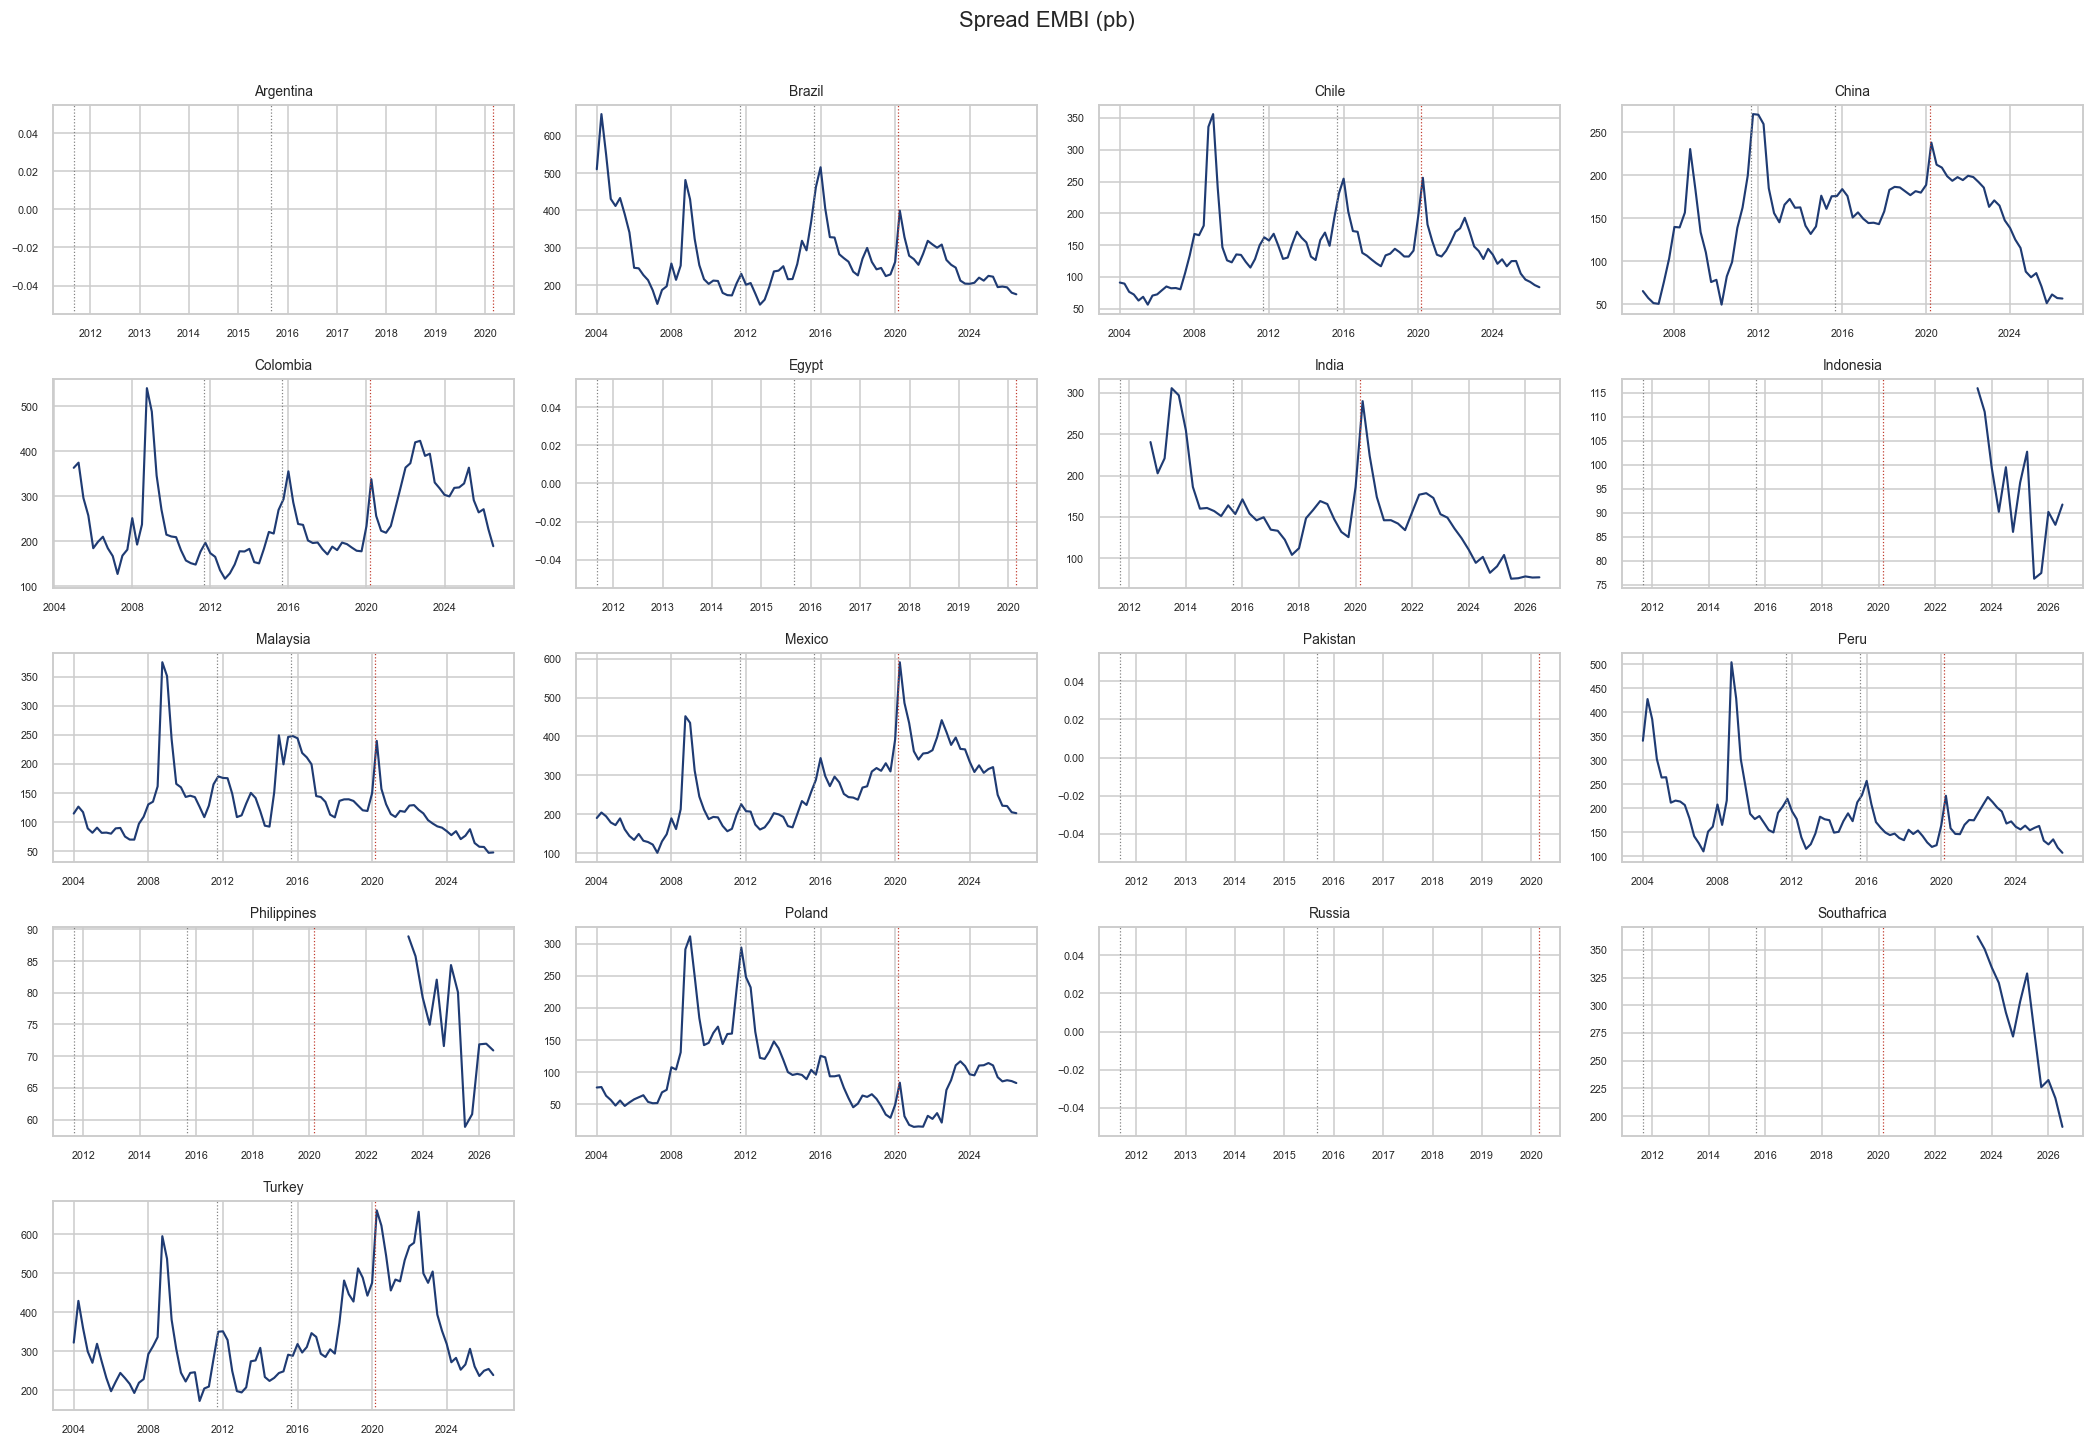

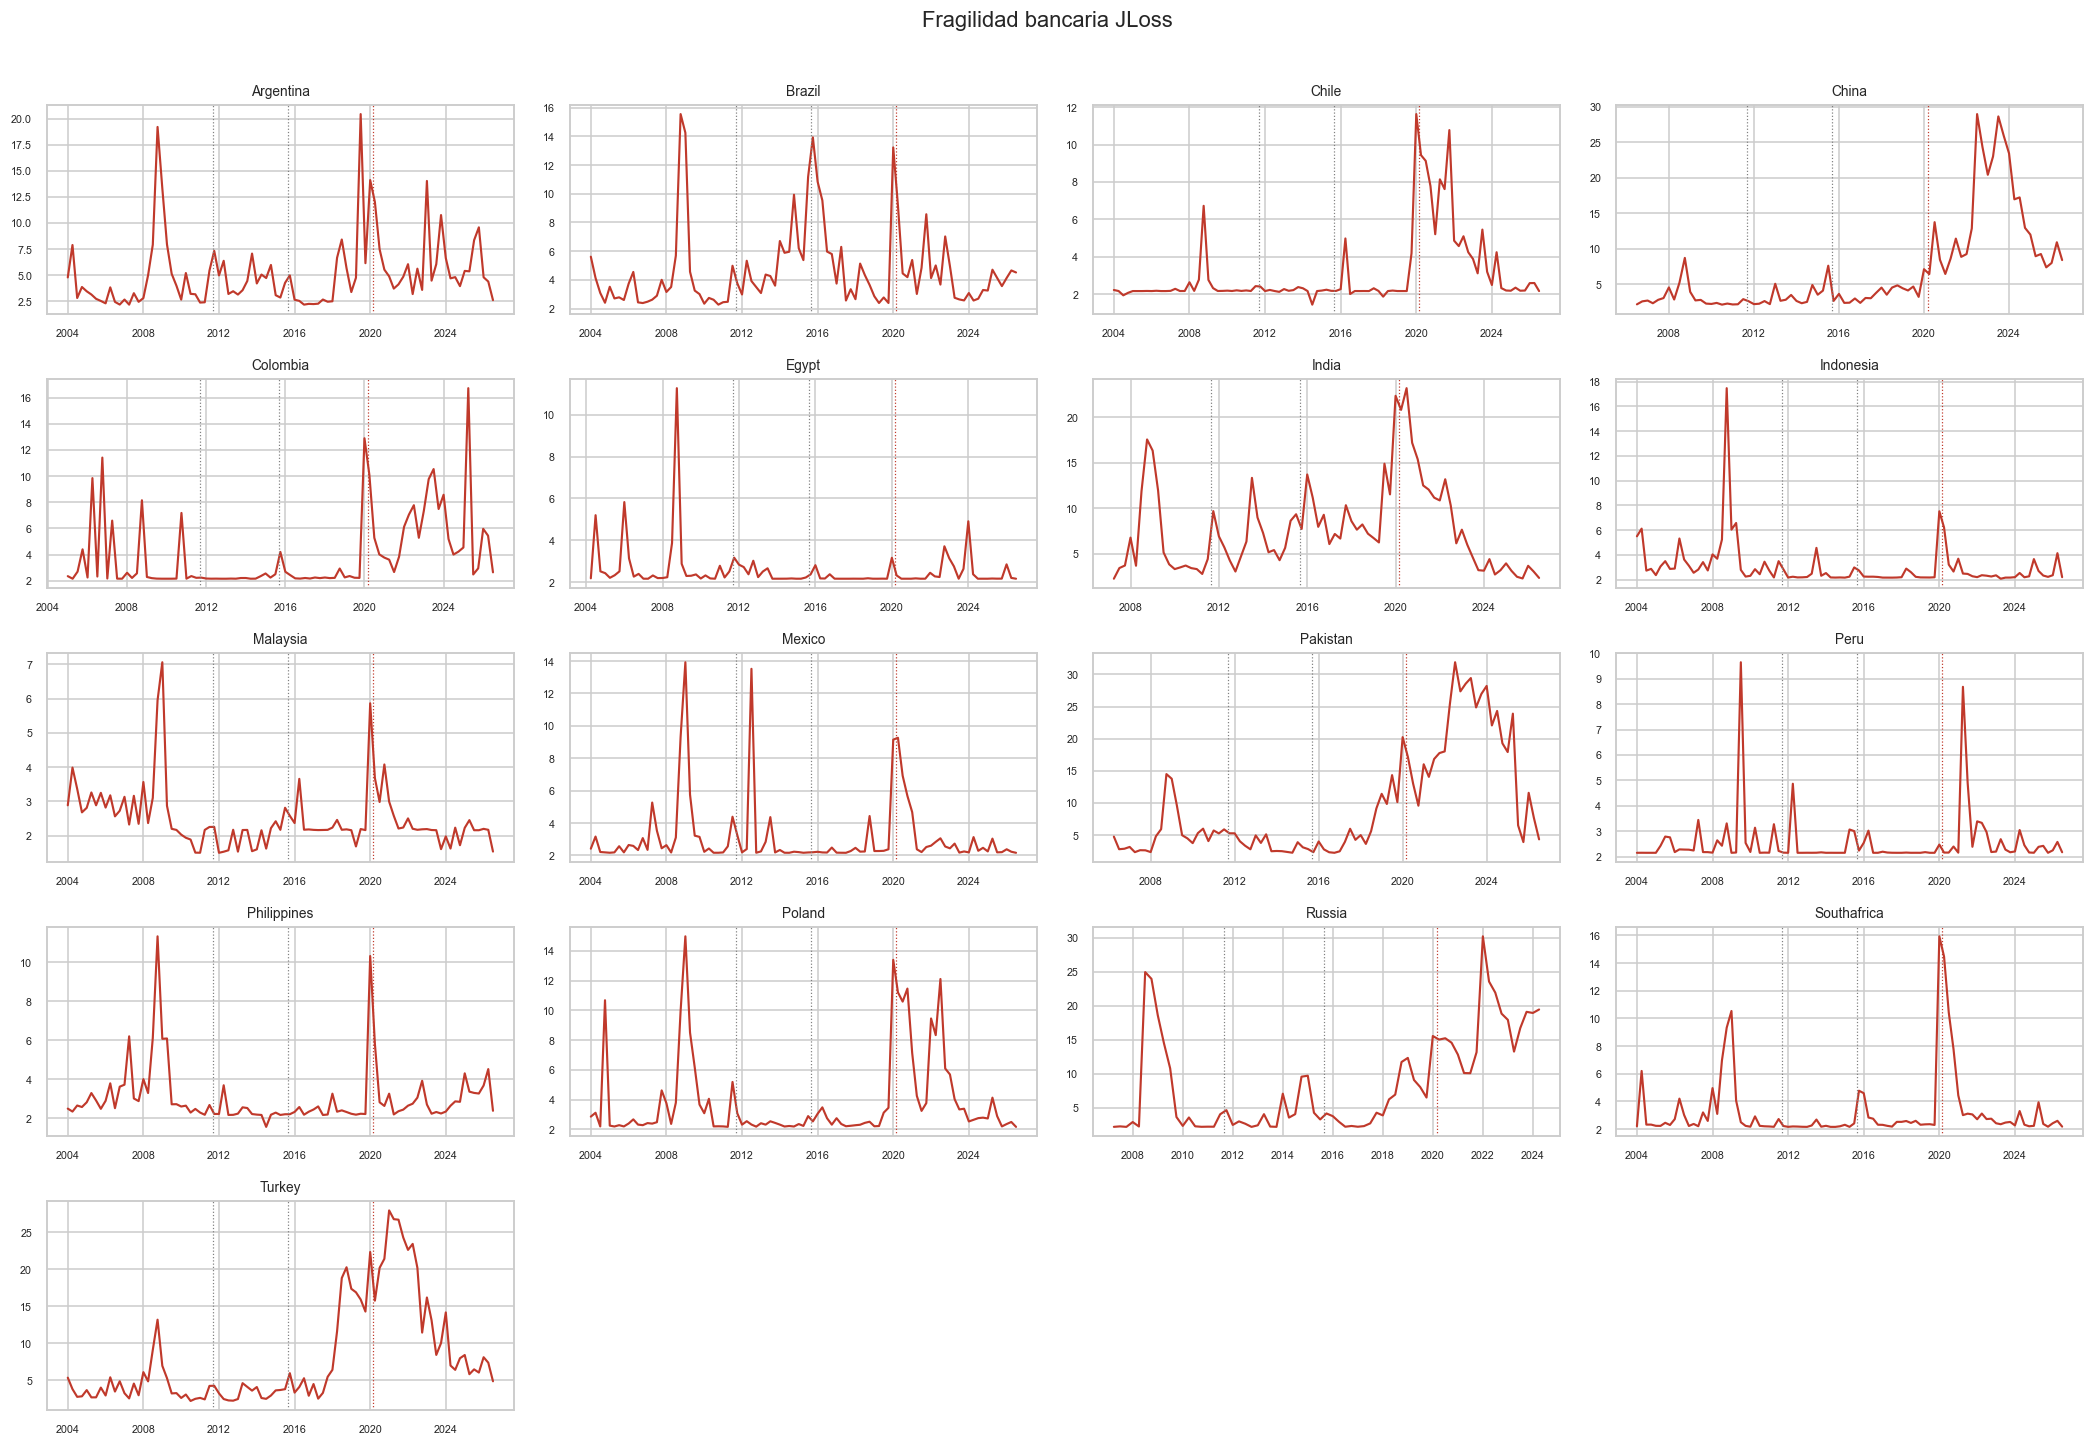

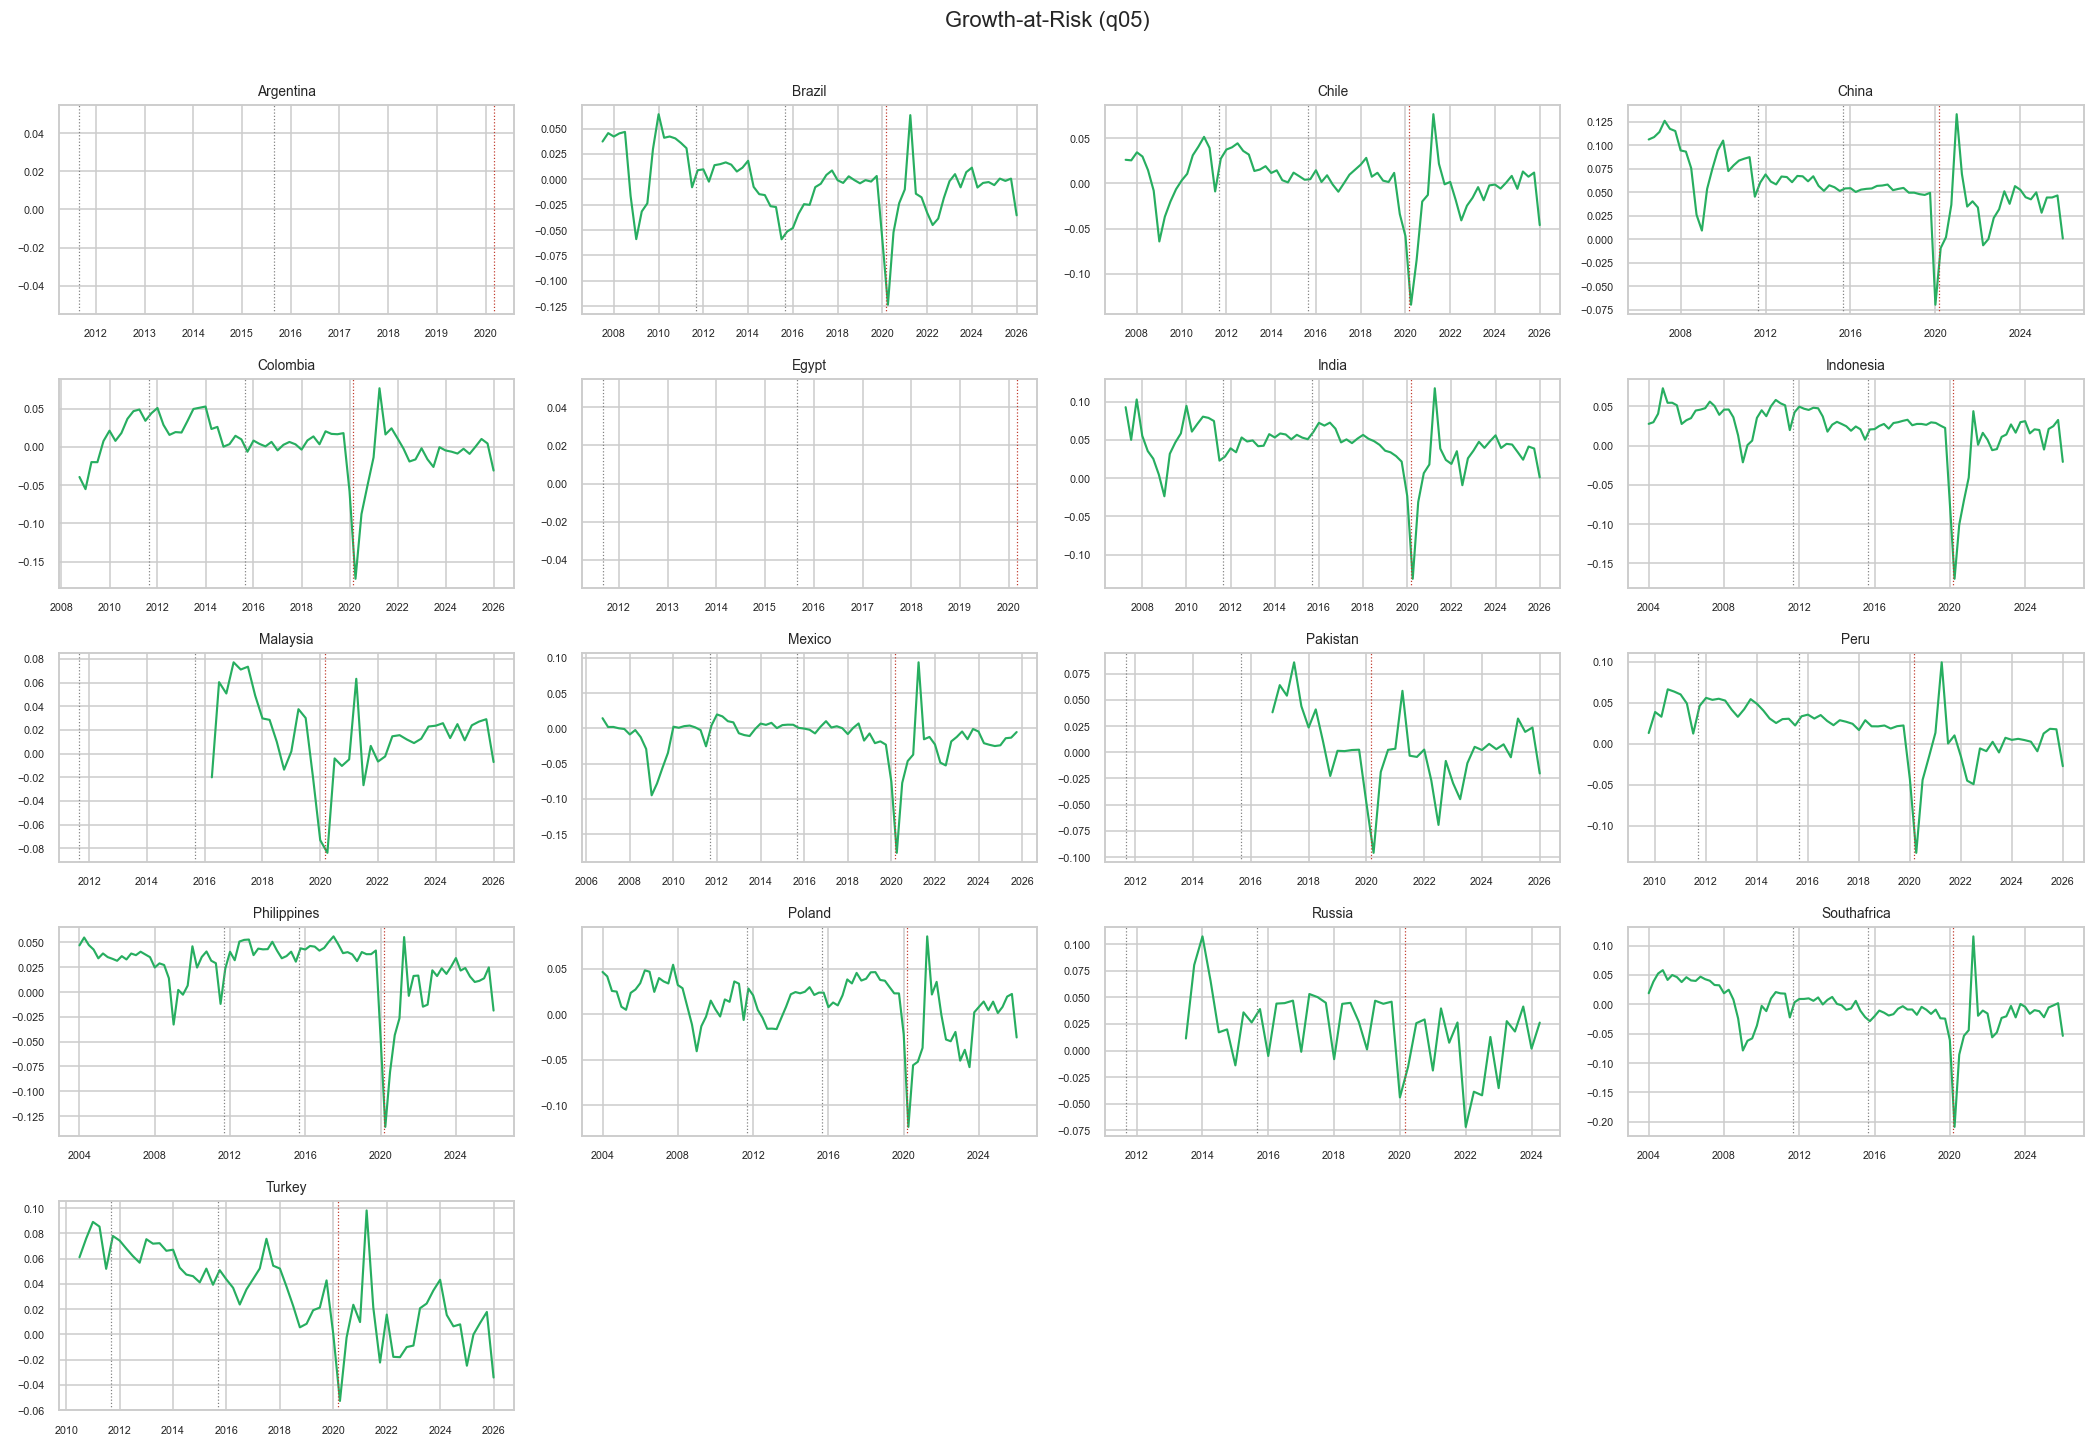

In [11]:
MARKERS = [('2011-09','grey'),('2015-09','grey'),('2020-03','#c0392b')]
def panel_timeseries(var, color='#1f3b73', data=None):
    data = df if data is None else data
    countries = sorted(data['country'].unique()); n = len(countries); nr, nc = grid(n)
    fig, axes = plt.subplots(nr, nc, figsize=(4.8*nc, 2.6*nr)); axes = np.atleast_1d(axes).ravel()
    for i,c in enumerate(countries):
        g = data[data.country==c].sort_values('date')
        axes[i].plot(g['date'], g[var], color=color, lw=1.4)
        axes[i].set_title(c.capitalize(), fontsize=9); axes[i].tick_params(labelsize=7)
        for yr,col in MARKERS: axes[i].axvline(pd.Timestamp(yr), color=col, ls=':', lw=.8)
    for j in range(n, len(axes)): axes[j].axis('off')
    fig.suptitle(LABELS.get(var,var), y=1.01); plt.tight_layout()
panel_timeseries('EMBI_bps', '#1f3b73'); savefig('05_ts_embi'); plt.show()
panel_timeseries('JLoss',    '#c0392b'); savefig('05_ts_jloss'); plt.show()
panel_timeseries('GaR',      '#27ae60'); savefig('05_ts_gar'); plt.show()

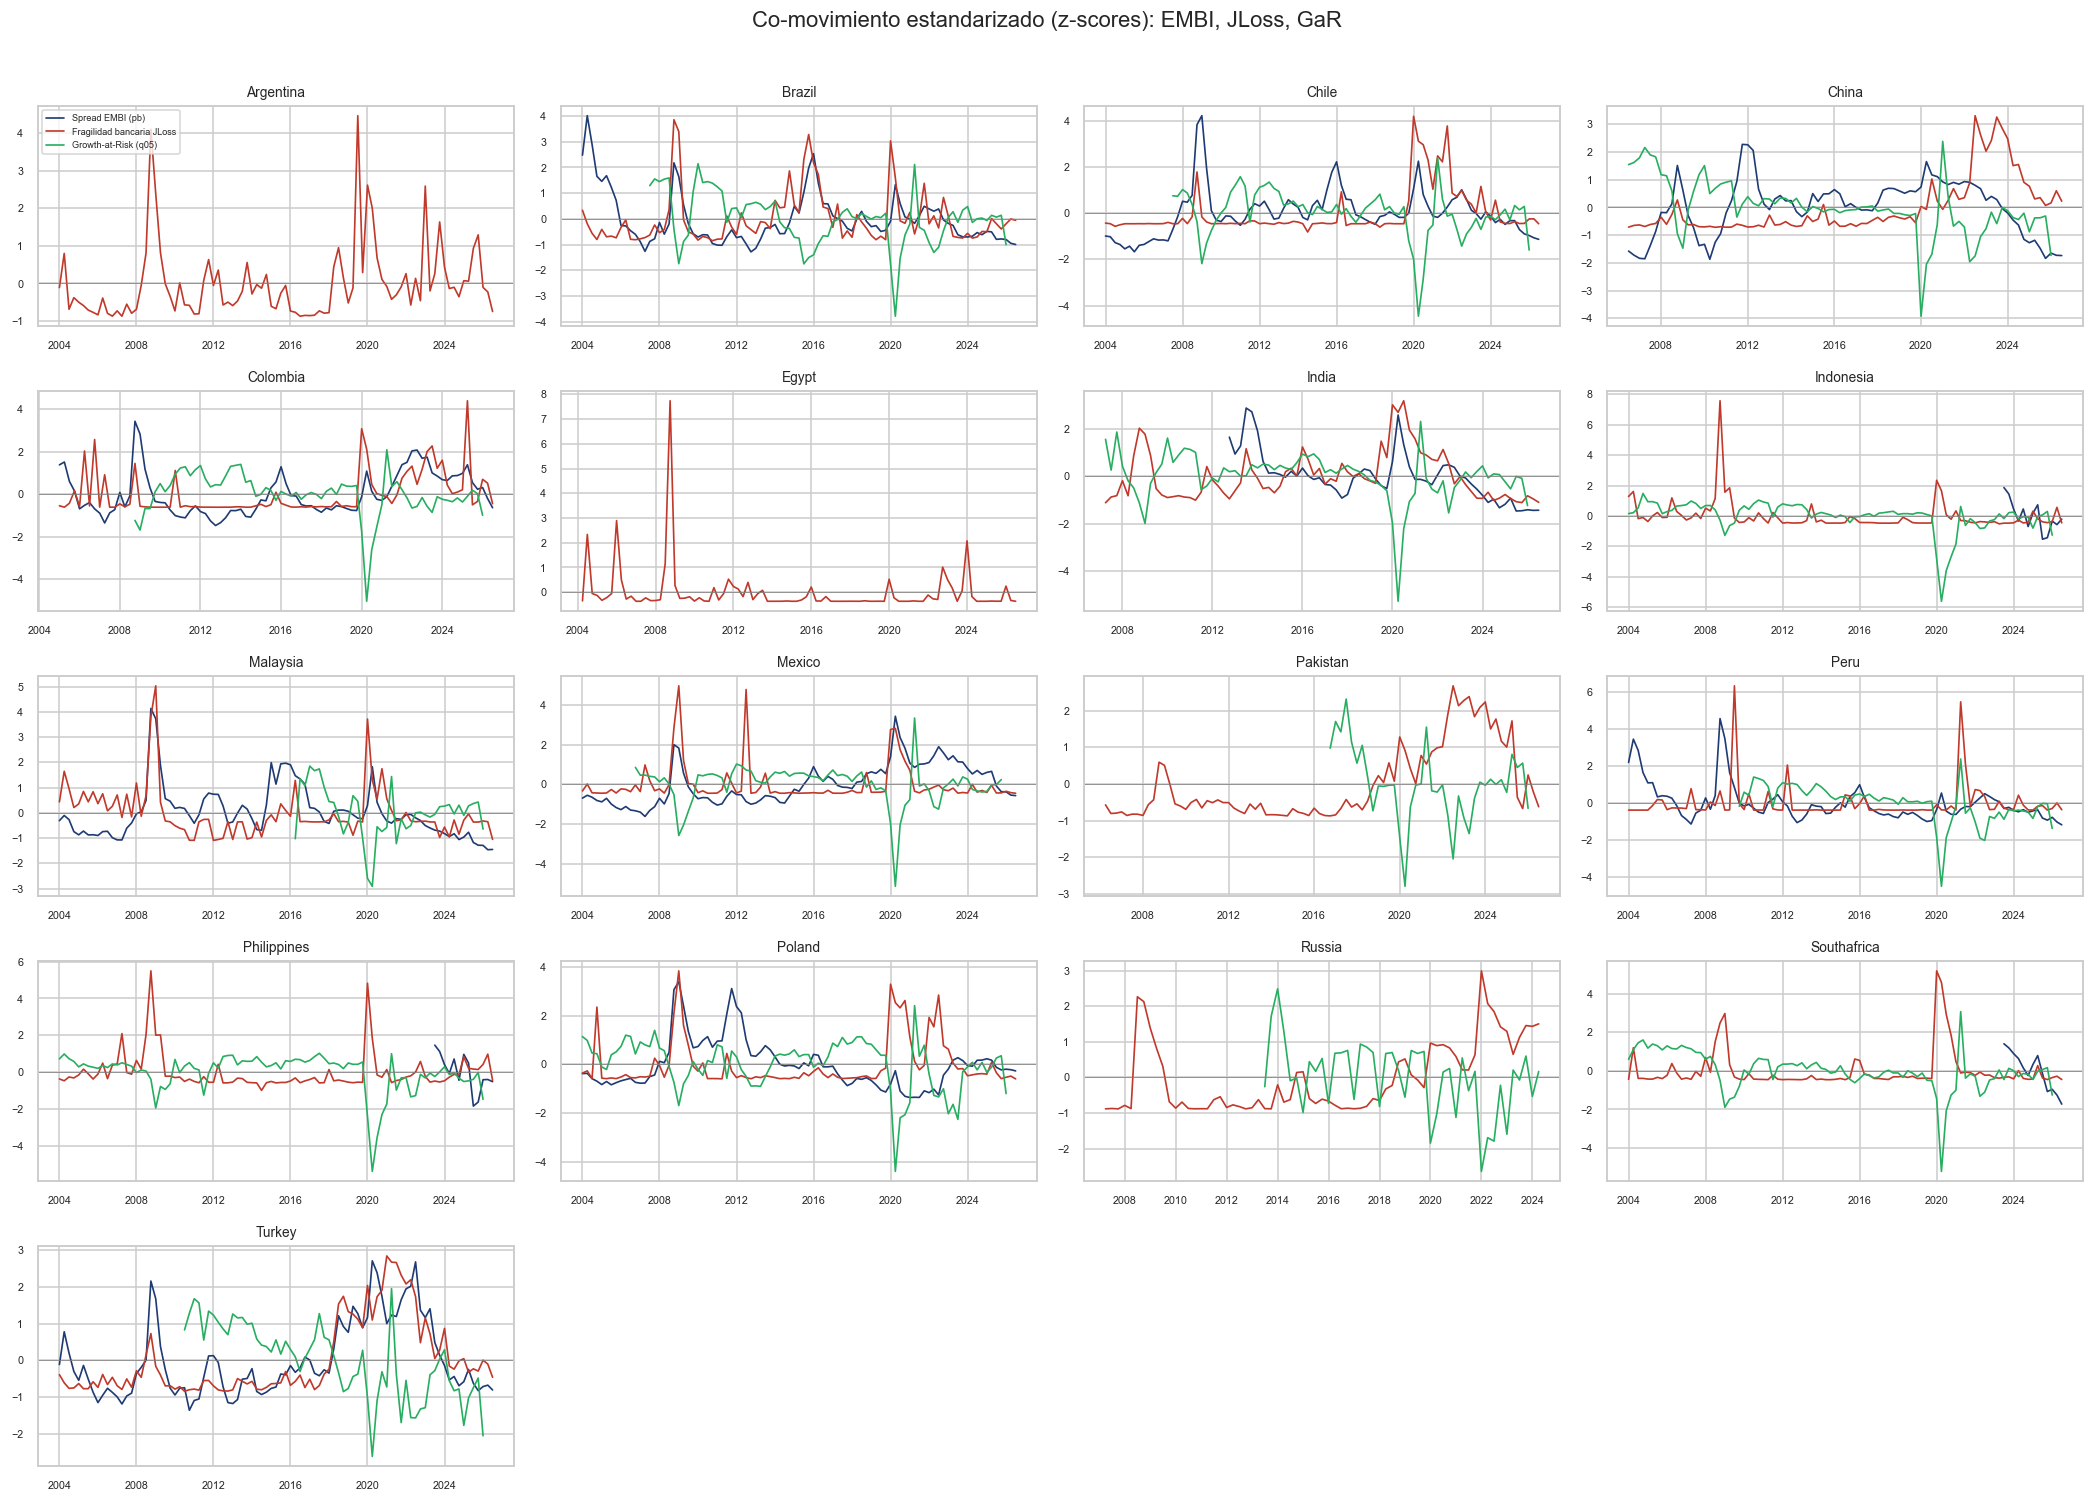

In [12]:
countries = sorted(df['country'].unique()); n = len(countries); nr, nc = grid(n)
fig, axes = plt.subplots(nr, nc, figsize=(4.8*nc, 2.7*nr)); axes = np.atleast_1d(axes).ravel()
trio = present(['EMBI_bps','JLoss','GaR']); cols3 = {'EMBI_bps':'#1f3b73','JLoss':'#c0392b','GaR':'#27ae60'}
for i,c in enumerate(countries):
    g = df[df.country==c].sort_values('date')
    for v in trio:
        z = (g[v]-g[v].mean())/g[v].std()
        axes[i].plot(g['date'], z, color=cols3[v], lw=1.1, label=LABELS.get(v,v))
    axes[i].set_title(c.capitalize(), fontsize=9); axes[i].tick_params(labelsize=7)
    axes[i].axhline(0, color='grey', lw=.5)
for j in range(n, len(axes)): axes[j].axis('off')
axes[0].legend(fontsize=6, loc='upper left')
fig.suptitle('Co-movimiento estandarizado (z-scores): EMBI, JLoss, GaR', y=1.01)
plt.tight_layout(); savefig('05_comovimiento'); plt.show()

## 7. Relación EMBI–JLoss–GaR y complementariedad

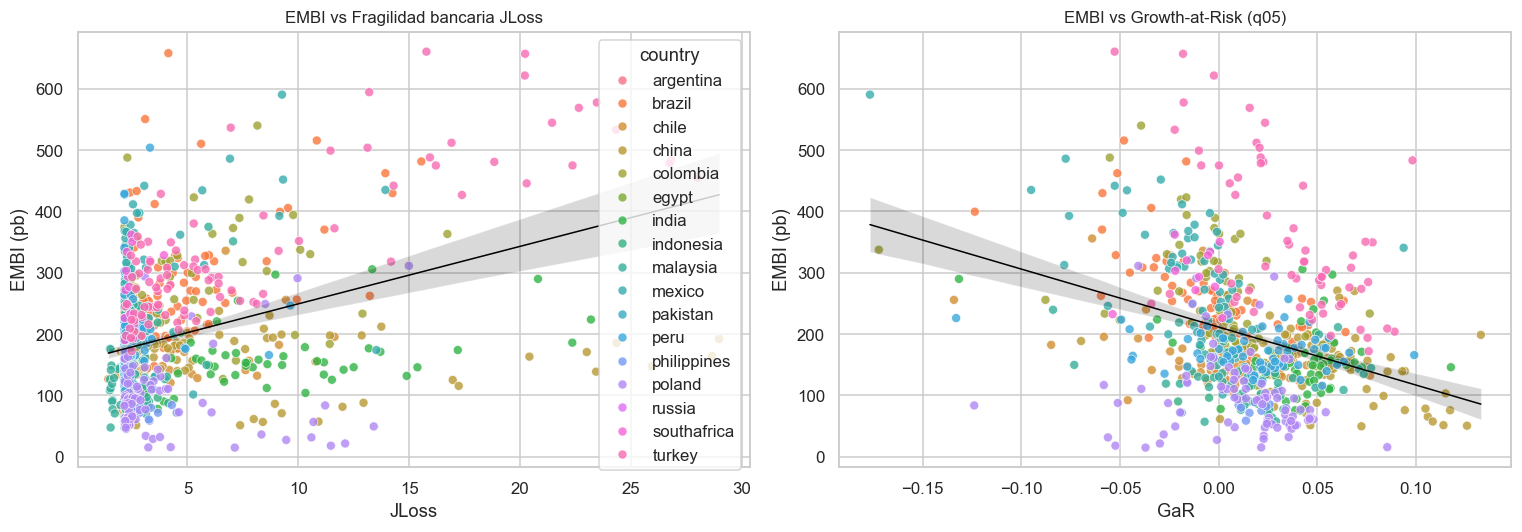

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax,v in zip(axes, ['JLoss','GaR']):
    sns.scatterplot(data=df, x=v, y='EMBI_bps', hue='country', ax=ax, s=35, alpha=.8)
    sns.regplot(data=df, x=v, y='EMBI_bps', scatter=False, ax=ax, color='black', line_kws={'lw':1})
    ax.set_title(f'EMBI vs {LABELS.get(v,v)}'); ax.set_ylabel('EMBI (pb)')
    if v != 'JLoss' and ax.legend_ is not None: ax.legend_.remove()
plt.tight_layout(); savefig('06_scatter_embi'); plt.show()

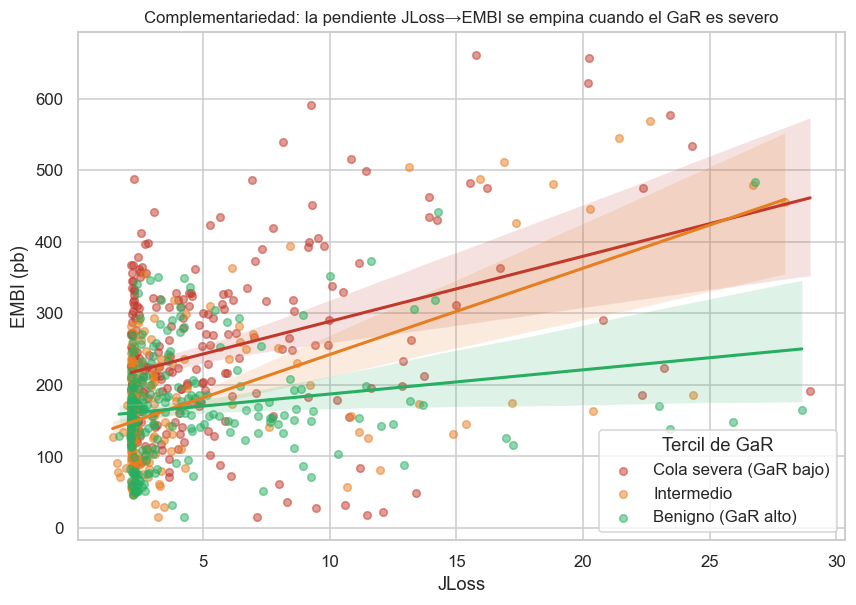

In [14]:
df['GaR_tercil'] = pd.qcut(df['GaR'], 3, labels=['Cola severa (GaR bajo)','Intermedio','Benigno (GaR alto)'])
palette = {'Cola severa (GaR bajo)':'#c0392b','Intermedio':'#e67e22','Benigno (GaR alto)':'#27ae60'}
fig, ax = plt.subplots(figsize=(9,6))
for terc,g in df.groupby('GaR_tercil', observed=True):
    sns.regplot(data=g, x='JLoss', y='EMBI_bps', scatter_kws={'s':25,'alpha':.5},
                line_kws={'lw':2}, color=palette[str(terc)], label=str(terc), ax=ax)
ax.set_title('Complementariedad: la pendiente JLoss→EMBI se empina cuando el GaR es severo')
ax.set_xlabel('JLoss'); ax.set_ylabel('EMBI (pb)'); ax.legend(title='Tercil de GaR')
savefig('06_complementariedad'); plt.show()

## 8. Correlaciones y multicolinealidad

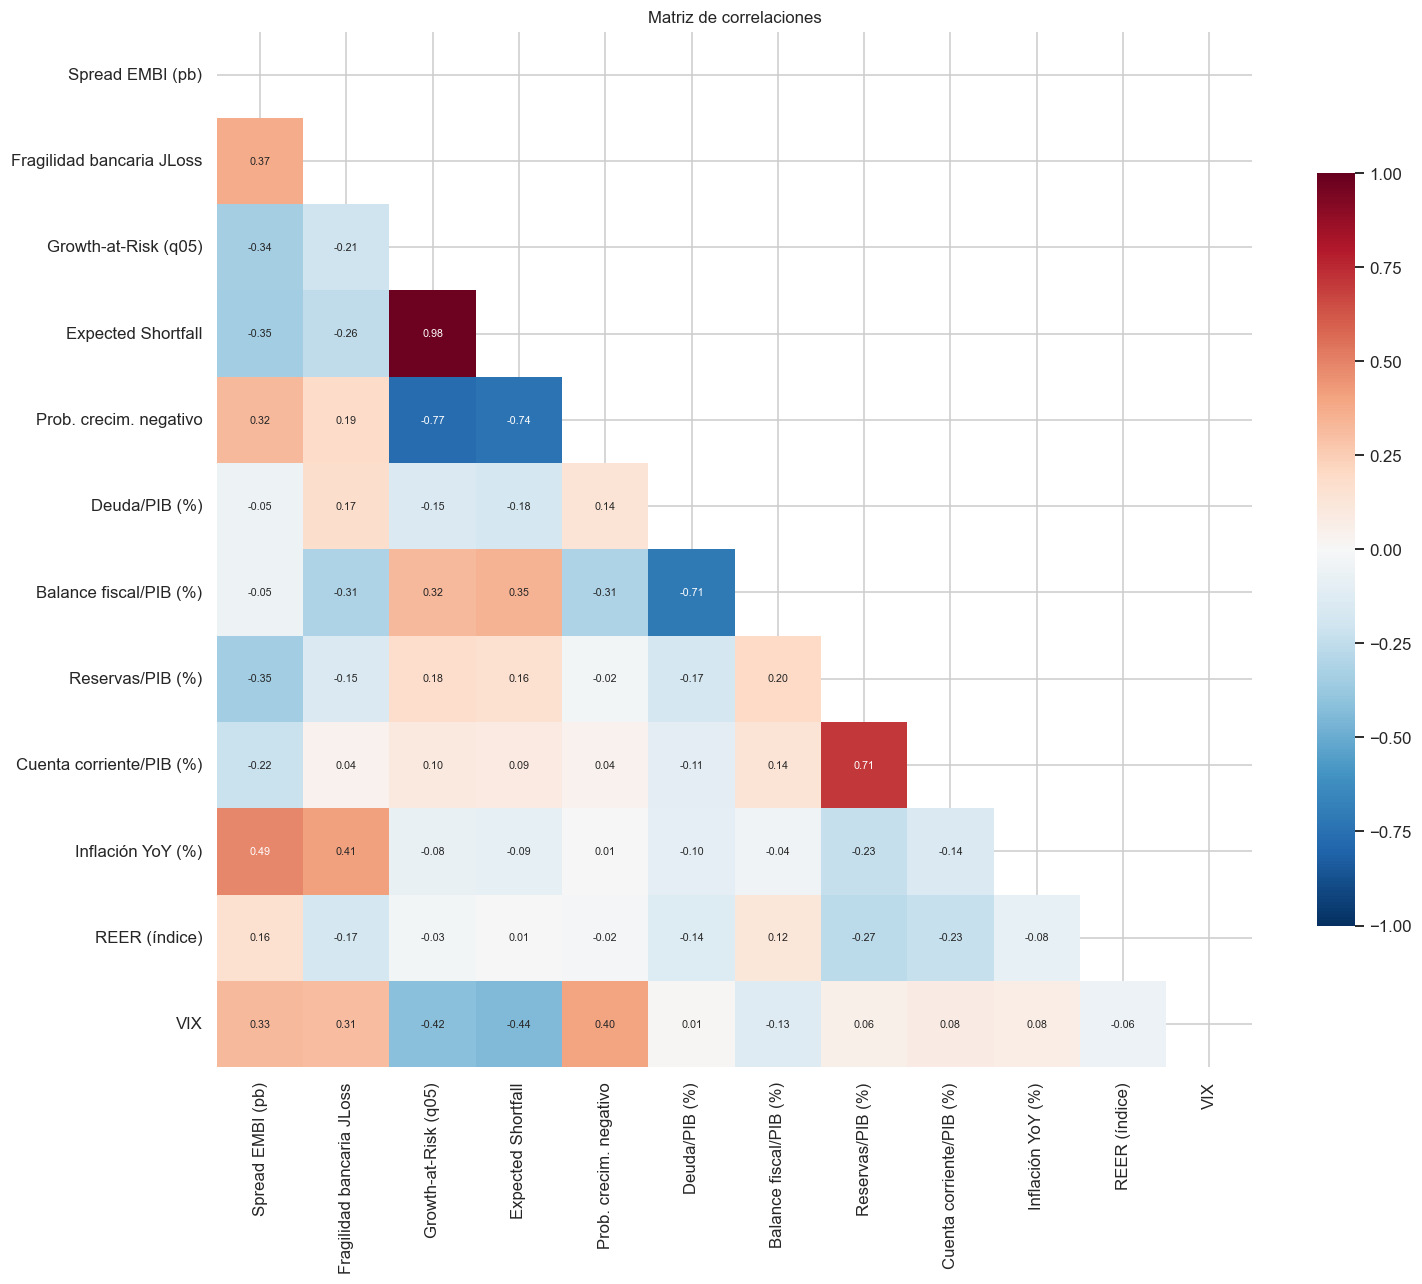


Pares con |corr|>0.6:
  Growth-at-Risk (q05) ~ Expected Shortfall: +0.979
  Growth-at-Risk (q05) ~ Prob. crecim. negativo: -0.766
  Expected Shortfall ~ Prob. crecim. negativo: -0.741
  Deuda/PIB (%) ~ Balance fiscal/PIB (%): -0.712
  Reservas/PIB (%) ~ Cuenta corriente/PIB (%): +0.705


In [15]:
corr_vars = list(dict.fromkeys(CORE + present(['g_GDP']) + CTRLS + ([VIXVAR] if VIXVAR else [])))
cm = df[corr_vars].corr(); lab = [LABELS.get(c,c) for c in corr_vars]
cm.index = lab; cm.columns = lab
fig, ax = plt.subplots(figsize=(1.0*len(corr_vars)+2, 0.9*len(corr_vars)+1))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink':.7}, annot_kws={'size':7}, ax=ax)
ax.set_title('Matriz de correlaciones'); plt.tight_layout(); savefig('07_correlaciones'); plt.show()
cm.round(3).to_csv(OUTDIR/'matriz_correlaciones.csv')
raw = df[corr_vars].corr()
print('\nPares con |corr|>0.6:')
for i in range(len(corr_vars)):
    for j in range(i+1, len(corr_vars)):
        if abs(raw.iloc[i,j]) > 0.6: print(f'  {lab[i]} ~ {lab[j]}: {raw.iloc[i,j]:+.3f}')

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
vif_vars = present(['JLoss','GaR'] + CTRLS + ([VIXVAR] if VIXVAR else []))
if len(vif_vars) >= 2:
    X = add_constant(df[vif_vars].dropna())
    vif = pd.DataFrame({'variable':[LABELS.get(v,v) for v in vif_vars],
        'VIF':[variance_inflation_factor(X.values, i+1) for i in range(len(vif_vars))]}).round(2)
    print(vif.to_string(index=False)); print('\nRegla: VIF>10 = multicolinealidad problemática.')
else:
    print('Insuficientes regresores continuos para VIF en esta base.')

                 variable    VIF
Fragilidad bancaria JLoss 1.7000
     Growth-at-Risk (q05) 1.3800
            Deuda/PIB (%) 2.1700
   Balance fiscal/PIB (%) 2.5000
         Reservas/PIB (%) 1.8300
 Cuenta corriente/PIB (%) 1.6600
        Inflación YoY (%) 1.3600
            REER (índice) 1.4500
                      VIX 1.3300

Regla: VIF>10 = multicolinealidad problemática.


## 9. Descomposición within/between y persistencia

In [17]:
def xtsum(d, var, group='country'):
    overall = d[var].std(); between = d.groupby(group)[var].mean().std()
    gmean = d.groupby(group)[var].transform('mean'); within = (d[var]-gmean + d[var].mean()).std()
    return overall, between, within
rows=[]
for v in CORE + present(['g_GDP']) + CTRLS:
    o,b,w = xtsum(df, v)
    rows.append({'variable':LABELS.get(v,v),'sd_total':o,'sd_between':b,'sd_within':w,'within/total': w/o if o else np.nan})
vardec = pd.DataFrame(rows).round(3); vardec.to_csv(OUTDIR/'descomposicion_within_between.csv', index=False)
print(vardec.to_string(index=False))

                 variable  sd_total  sd_between  sd_within  within/total
         Spread EMBI (pb)  107.4350     83.2690    77.2290        0.7190
Fragilidad bancaria JLoss    4.6400      2.3870     4.0520        0.8730
     Growth-at-Risk (q05)    0.0380      0.0190     0.0330        0.8690
       Expected Shortfall    0.0400      0.0190     0.0350        0.8780
   Prob. crecim. negativo    0.2130      0.0620     0.2040        0.9550
            Deuda/PIB (%)   20.6490     18.9670    11.2770        0.5460
   Balance fiscal/PIB (%)    2.6840      1.8460     2.0200        0.7520
         Reservas/PIB (%)   10.0250      9.0260     4.5290        0.4520
 Cuenta corriente/PIB (%)    4.0420      3.3160     2.3990        0.5930
        Inflación YoY (%)    7.5570      4.3160     6.1490        0.8140
            REER (índice)   19.6560     13.6250    14.5510        0.7400


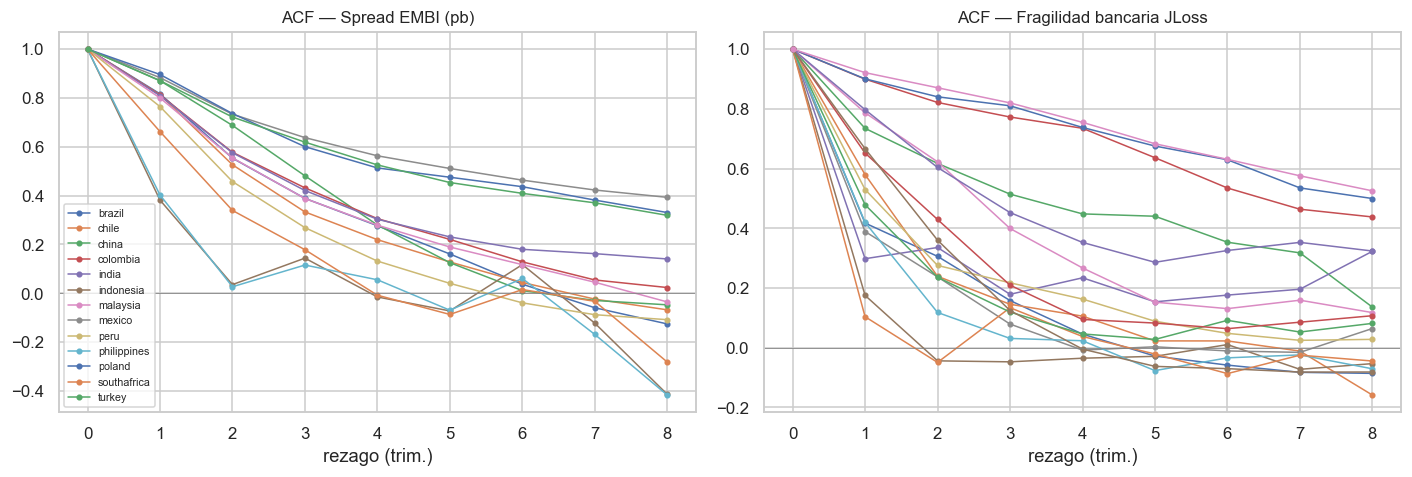

Alta persistencia -> SE Driscoll-Kraay y specs dinámicas de robustez en las regresiones.


In [18]:
from statsmodels.tsa.stattools import acf
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax,v in zip(axes, ['EMBI_bps','JLoss']):
    for c,g in df.groupby('country'):
        s = g.sort_values('t')[v].dropna().values
        if len(s) > 9:
            a = acf(s, nlags=8, fft=False); ax.plot(range(len(a)), a, marker='o', ms=3, label=c, lw=1)
    ax.axhline(0, color='grey', lw=.5); ax.set_title(f'ACF — {LABELS.get(v,v)}'); ax.set_xlabel('rezago (trim.)')
axes[0].legend(fontsize=7)
plt.tight_layout(); savefig('09_persistencia'); plt.show()
print('Alta persistencia -> SE Driscoll-Kraay y specs dinámicas de robustez en las regresiones.')

## 10. Regímenes de VIX, atípicos y archivos

In [19]:
if VIXVAR:
    df['regimen_VIX'] = pd.qcut(df[VIXVAR], 3, labels=['VIX bajo','VIX medio','VIX alto'])
    tab = df.groupby('regimen_VIX', observed=True)[present(['EMBI_bps','JLoss','GaR','prob_neg'])].mean().round(3)
    print(tab.to_string()); tab.to_csv(OUTDIR/'medias_por_regimen_VIX.csv')
else:
    print('Sin variable VIX en esta base.')

             EMBI_bps  JLoss     GaR  prob_neg
regimen_VIX                                   
VIX bajo     178.7410 3.7430  0.0270    0.0400
VIX medio    188.4170 4.2080  0.0240    0.0470
VIX alto     227.9620 6.1300 -0.0040    0.1960


In [20]:
z = (df[CORE] - df[CORE].mean())/df[CORE].std()
out = df.loc[(z.abs()>3).any(axis=1), ['country','quarter']+CORE]
print(f'Observaciones con |z|>3 en alguna variable central: {len(out)}')
out.round(3)

Observaciones con |z|>3 en alguna variable central: 98


,country,quarter,EMBI_bps,JLoss,GaR,ES,prob_neg
19,argentina,2008Q4,NaN,19.2080,NaN,NaN,NaN
62,argentina,2019Q3,NaN,20.4400,NaN,NaN,NaN
92,brazil,2004Q2,658.1110,4.1400,NaN,NaN,NaN
93,brazil,2004Q3,550.5780,3.0950,NaN,NaN,NaN
137,brazil,2015Q3,370.4380,11.1760,-0.0590,-0.0730,0.9260
...,...,...,...,...,...,...,...
1467,turkey,2021Q3,478.6560,26.7330,0.0210,-0.0020,0.0270
1468,turkey,2021Q4,533.2580,24.3190,-0.0220,-0.0710,0.1050
1469,turkey,2022Q1,568.9840,22.6440,0.0160,-0.0040,0.0300
1470,turkey,2022Q2,577.6770,23.4560,-0.0180,-0.0370,0.0980


---
# 13. Análisis del GaR: volatilidad, anchura de colas y forma de la distribución

El panel Bloomberg trae los momentos completos de la distribución condicional del crecimiento
que estima el motor GaR (regresión cuantílica pooled, 18 países): `GaR` (cuantil 5%), `ES`
(*Expected Shortfall* de la cola izquierda), `std` (dispersión condicional), `gar_mean` (media
condicional), `iqr_05_95` (ancho intercuantil 5–95), y los parámetros del ajuste skew-t
(`scale_st`, `skew_st`, `nu_st`). No hace falta base auxiliar.


In [21]:
gar = df.copy()
print('Países en el panel:', sorted(gar['country'].unique()))
gar[[c for c in ['country','quarter','GaR','GaR_st','ES','std','skew','prob_neg'] if c in gar.columns]].head()


Países en el panel: ['argentina', 'brazil', 'chile', 'china', 'colombia', 'egypt', 'india', 'indonesia', 'malaysia', 'mexico', 'pakistan', 'peru', 'philippines', 'poland', 'russia', 'southafrica', 'turkey']


,country,quarter,GaR,GaR_st,ES,std,skew,prob_neg
0,argentina,2004Q1,NaN,NaN,NaN,NaN,NaN,NaN
1,argentina,2004Q2,NaN,NaN,NaN,NaN,NaN,NaN
2,argentina,2004Q3,NaN,NaN,NaN,NaN,NaN,NaN
3,argentina,2004Q4,NaN,NaN,NaN,NaN,NaN,NaN
4,argentina,2005Q1,NaN,NaN,NaN,NaN,NaN,NaN


## 13.1 Volatilidad del GaR

(i) **dispersión condicional** `std` estimada en cada corte y (ii) **volatilidad realizada** del GaR (desviación estándar móvil de 4 trimestres).

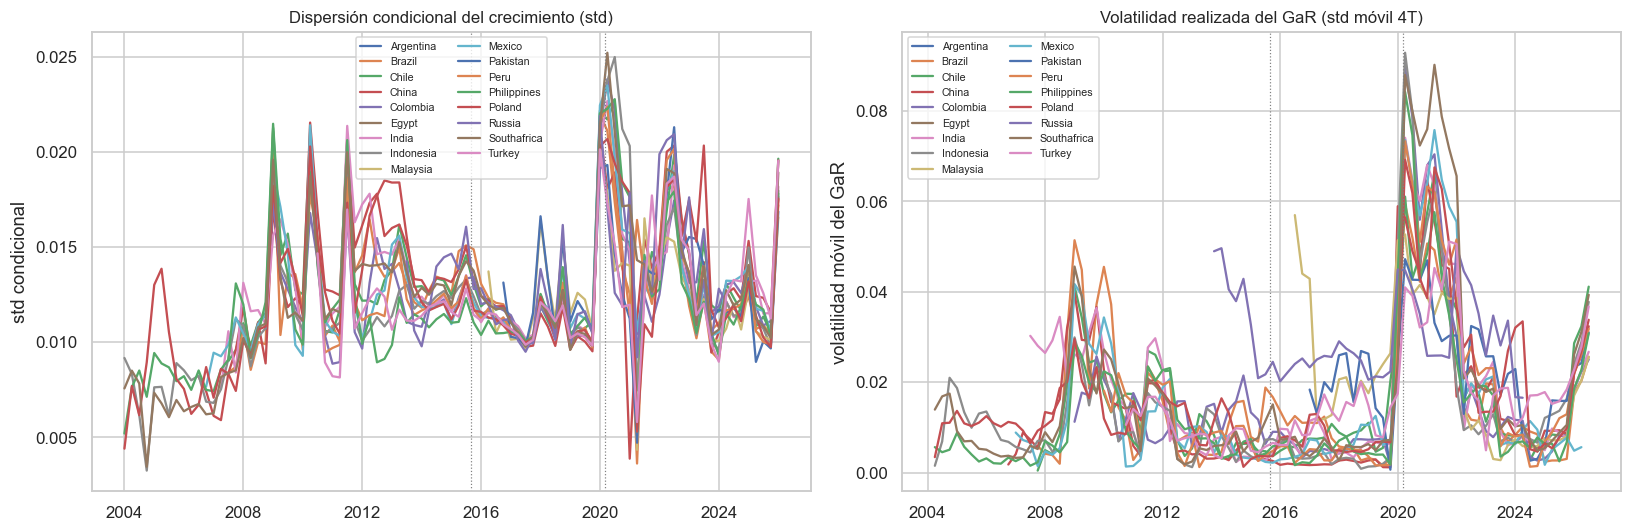

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for c, g in gar.groupby('country'):
    axes[0].plot(g['date'], g['std'], lw=1.5, label=c.capitalize())
axes[0].set_title('Dispersión condicional del crecimiento (std)')
axes[0].set_ylabel('std condicional'); axes[0].legend(fontsize=7, ncol=2)
for yr in ['2015-09','2020-03']: axes[0].axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)
gar['GaR_vol4'] = gar.groupby('country')['GaR'].transform(lambda s: s.rolling(4, min_periods=2).std())
for c, g in gar.groupby('country'):
    axes[1].plot(g['date'], g['GaR_vol4'], lw=1.5, label=c.capitalize())
axes[1].set_title('Volatilidad realizada del GaR (std móvil 4T)')
axes[1].set_ylabel('volatilidad móvil del GaR'); axes[1].legend(fontsize=7, ncol=2)
for yr in ['2015-09','2020-03']: axes[1].axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)
plt.tight_layout(); savefig('13_volatilidad_gar'); plt.show()

## 13.2 Anchura de las colas y su evolución temporal

Intervalo condicional 5–95% (percentil 5 = `GaR`; percentil 95 = `GaR + iqr_05_95`), media
condicional (`gar_mean`) y *Expected Shortfall* (cola izquierda). Las colas se ensanchan en los
episodios de estrés.


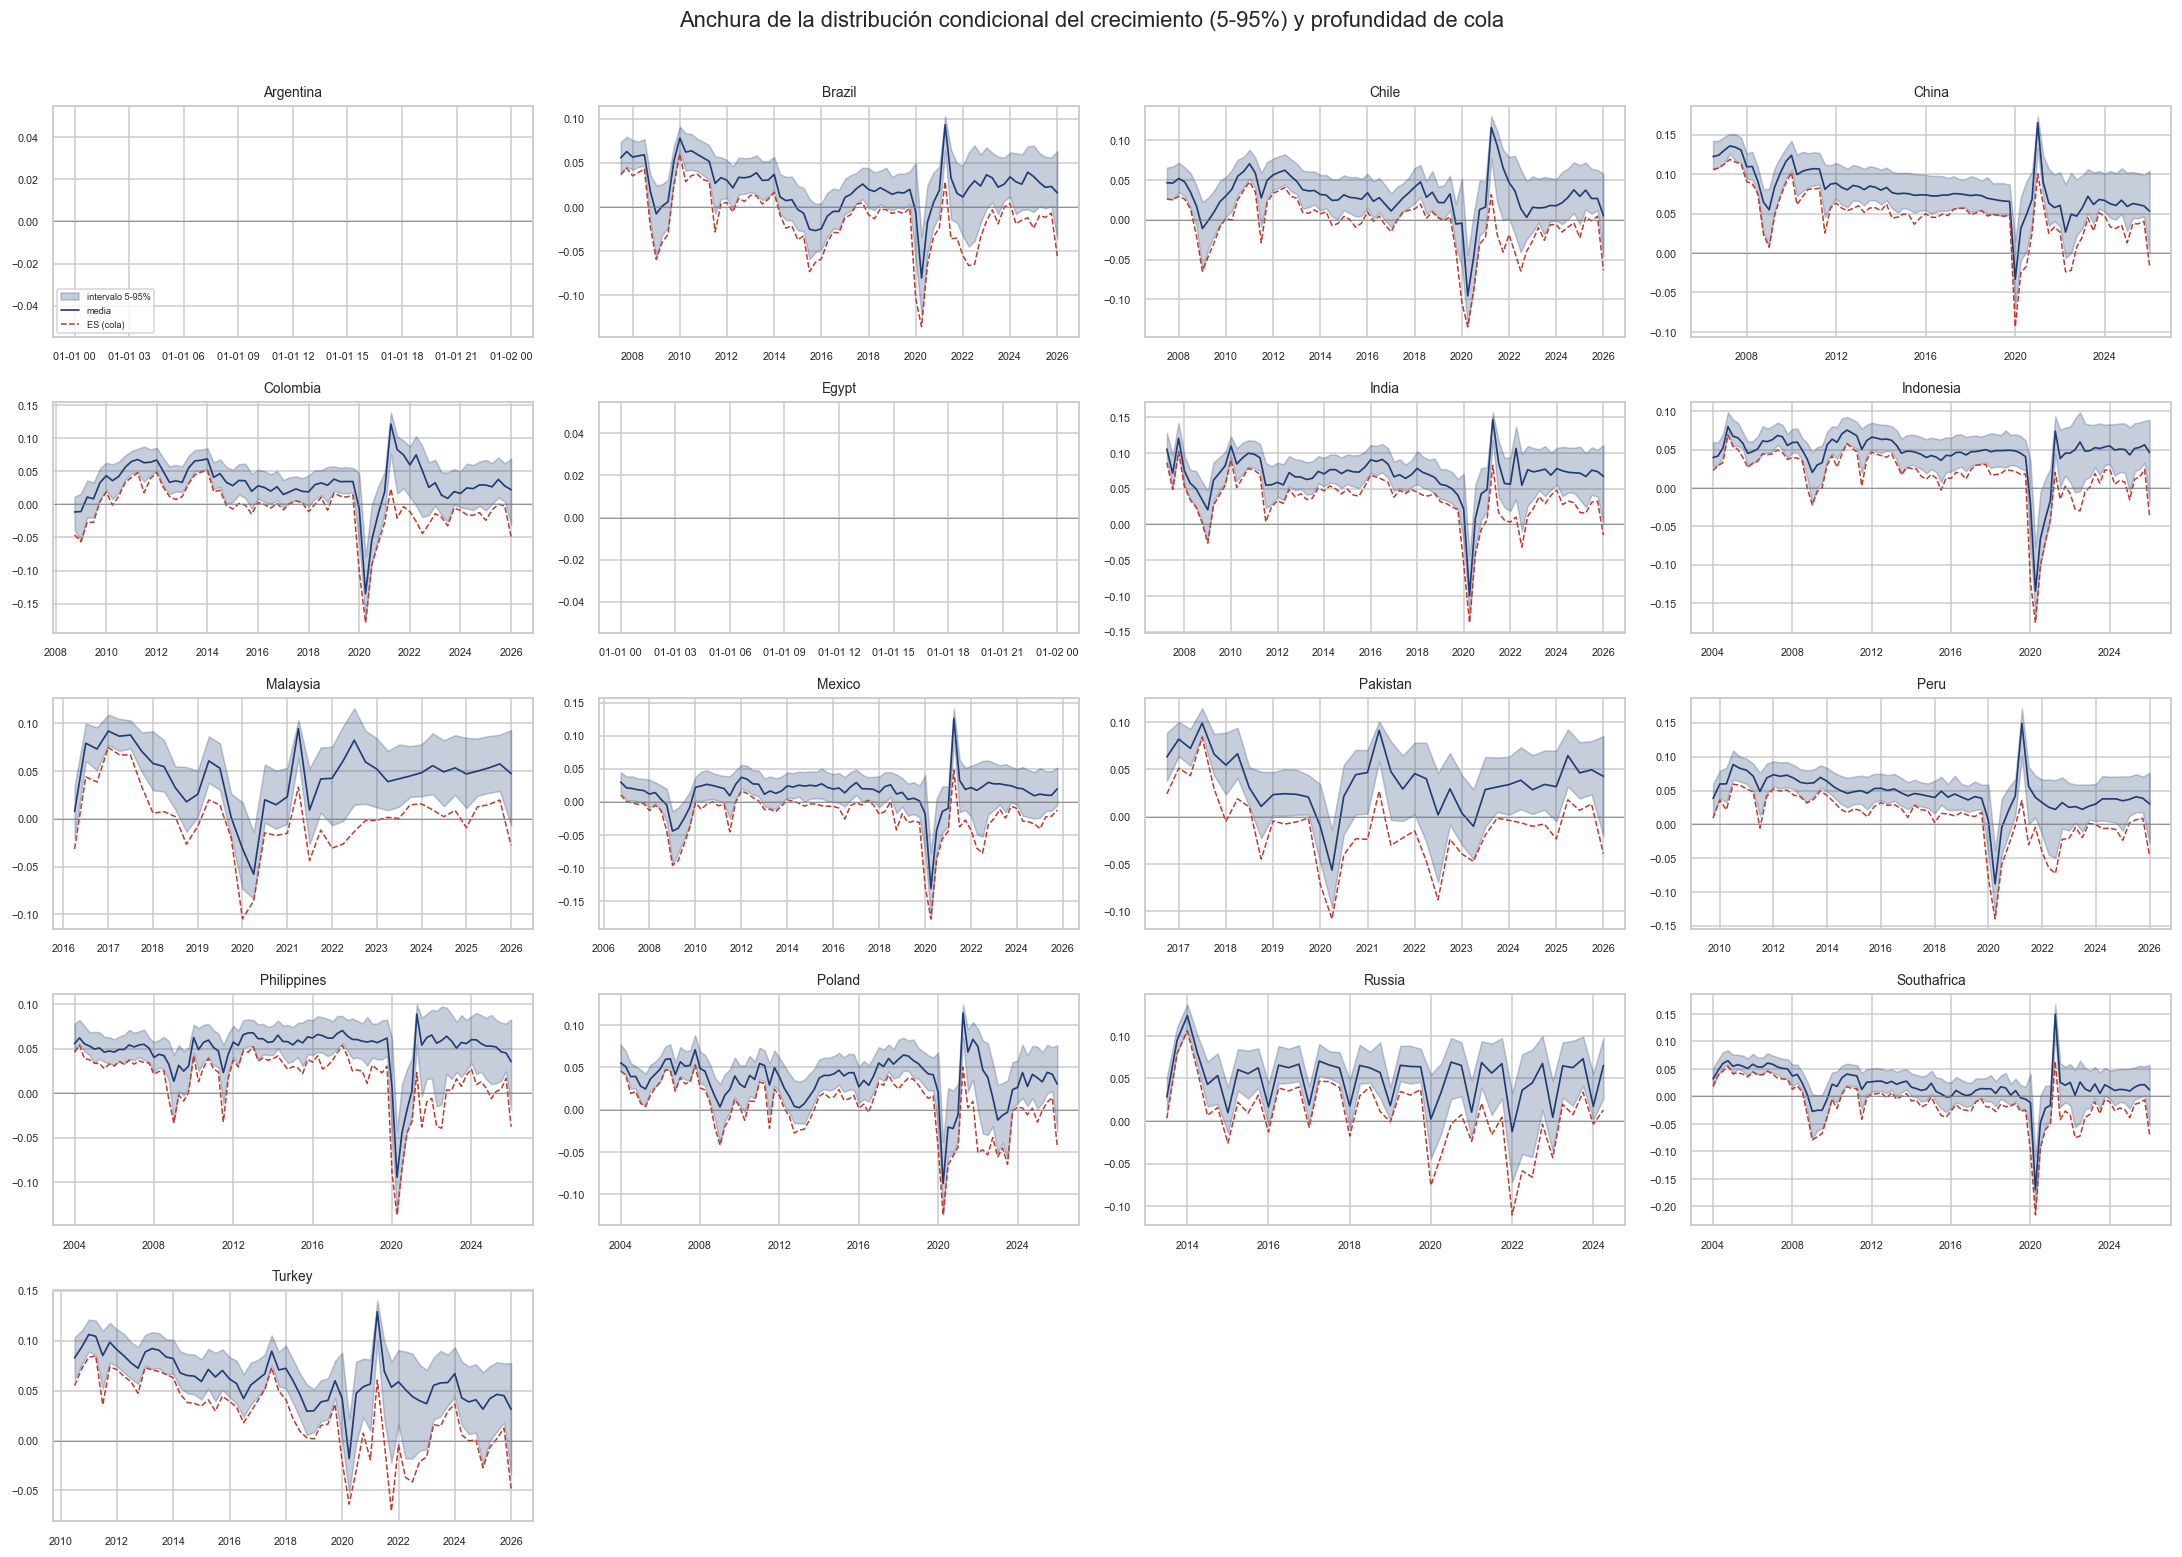

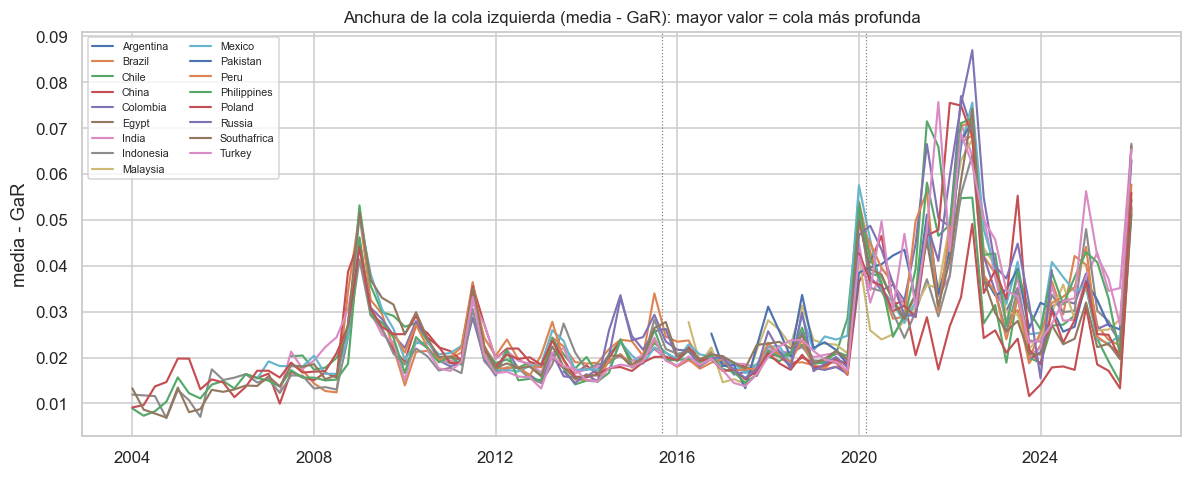

In [23]:
countries = sorted(gar['country'].unique()); n = len(countries); nr, nc = grid(n)
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 2.8*nr)); axes = np.atleast_1d(axes).ravel()
for i, c in enumerate(countries):
    g = gar[gar.country==c].sort_values('date')
    q05 = g['GaR']; q95 = g['GaR'] + g['iqr_05_95']
    axes[i].fill_between(g['date'], q05, q95, alpha=.25, color='#1f3b73', label='intervalo 5-95%')
    axes[i].plot(g['date'], g['gar_mean'], color='#1f3b73', lw=1.1, label='media')
    axes[i].plot(g['date'], g['ES'], color='#c0392b', lw=1.0, ls='--', label='ES (cola)')
    axes[i].axhline(0, color='grey', lw=.5); axes[i].set_title(c.capitalize(), fontsize=9); axes[i].tick_params(labelsize=7)
for j in range(n, len(axes)): axes[j].axis('off')
axes[0].legend(fontsize=6, loc='lower left')
fig.suptitle('Anchura de la distribución condicional del crecimiento (5-95%) y profundidad de cola', y=1.01)
plt.tight_layout(); savefig('13_anchura_colas'); plt.show()

fig, ax = plt.subplots(figsize=(11,4.5))
for c, g in gar.groupby('country'): ax.plot(g['date'], g['gar_mean'] - g['GaR'], lw=1.4, label=c.capitalize())
ax.set_title('Anchura de la cola izquierda (media - GaR): mayor valor = cola más profunda')
ax.set_ylabel('media - GaR'); ax.legend(fontsize=7, ncol=2)
for yr in ['2015-09','2020-03']: ax.axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)
plt.tight_layout(); savefig('13_cola_izquierda'); plt.show()


## 13.3 Forma de la distribución del GaR en momentos específicos

Densidad condicional **skew-t** (Azzalini; Adrian, Boyarchenko & Giannone, 2019) a partir de
los parámetros estimados —escala (`scale_st`), asimetría (`skew_st`), grados de libertad
(`nu_st`)— recuperando la localización desde la media condicional. Se contrasta un trimestre
de **estrés** (GaR más negativo) con uno **benigno** para un país de referencia, marcando el
GaR (q05) y el ES.


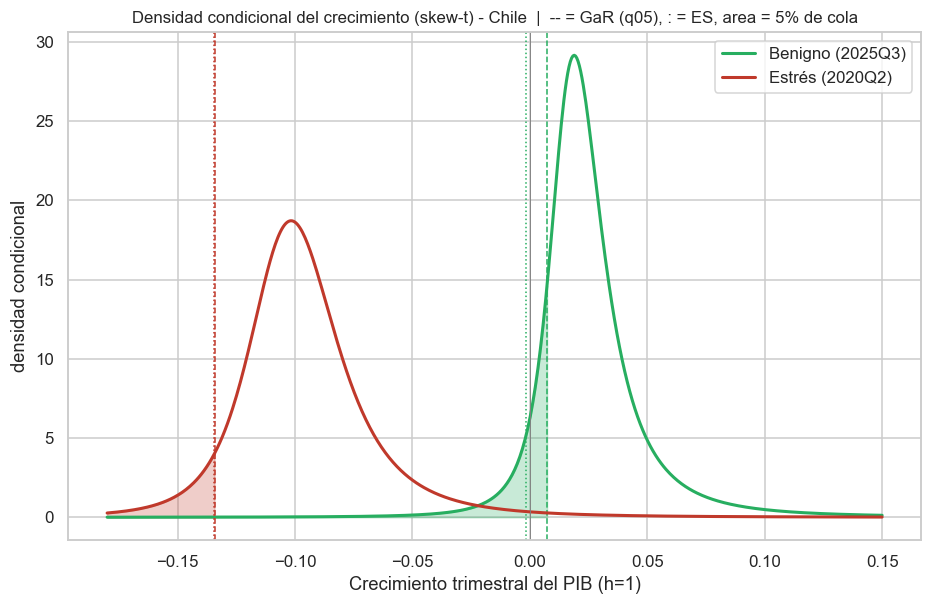

2025Q3: q05 skew-t reconstruido=-0.0026 | GaR_st reportado=0.0077 | GaR directo=0.0075
2020Q2: q05 skew-t reconstruido=-0.1365 | GaR_st reportado=-0.1341 | GaR directo=-0.1341


In [24]:
from scipy.stats import t as student_t
from scipy.special import gammaln
from scipy.integrate import cumulative_trapezoid

def skewt_pdf(y, xi, omega, alpha, nu):
    z = (y - xi) / omega
    arg = alpha * z * np.sqrt((nu + 1) / (z**2 + nu))
    return (2/omega) * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)
def xi_from_mean(mean, omega, alpha, nu):
    delta = alpha / np.sqrt(1 + alpha**2)
    b = np.sqrt(nu/np.pi) * np.exp(gammaln((nu-1)/2) - gammaln(nu/2))
    return mean - omega * delta * b

REF = 'chile' if 'chile' in set(gar['country']) else sorted(gar['country'].unique())[0]
ch = gar[gar.country == REF].dropna(subset=['scale_st','skew_st','nu_st','gar_mean','GaR']).copy()
q_stress = ch.loc[ch['GaR'].idxmin(), 'quarter']
q_calm   = ch.loc[(ch['GaR'] - ch['GaR'].median()).abs().idxmin(), 'quarter']

fig, ax = plt.subplots(figsize=(10, 6)); ygrid = np.linspace(-0.18, 0.15, 600)
for q, col, lab in [(q_calm, '#27ae60', f'Benigno ({q_calm})'), (q_stress, '#c0392b', f'Estrés ({q_stress})')]:
    r = ch[ch.quarter == q].iloc[0]
    xi = xi_from_mean(r['gar_mean'], r['scale_st'], r['skew_st'], r['nu_st'])
    dens = skewt_pdf(ygrid, xi, r['scale_st'], r['skew_st'], r['nu_st'])
    ax.plot(ygrid, dens, color=col, lw=2, label=lab)
    tail = ygrid <= r['GaR']; ax.fill_between(ygrid[tail], dens[tail], alpha=.25, color=col)
    ax.axvline(r['GaR'], color=col, ls='--', lw=1); ax.axvline(r['ES'], color=col, ls=':', lw=1)
ax.axvline(0, color='grey', lw=.6)
ax.set_xlabel('Crecimiento trimestral del PIB (h=1)'); ax.set_ylabel('densidad condicional')
ax.set_title('Densidad condicional del crecimiento (skew-t) - ' + REF.capitalize() + '  |  -- = GaR (q05), : = ES, area = 5% de cola')
ax.legend(); savefig('13_curva_gar'); plt.show()

for q in [q_calm, q_stress]:
    r = ch[ch.quarter == q].iloc[0]
    xi = xi_from_mean(r['gar_mean'], r['scale_st'], r['skew_st'], r['nu_st'])
    d = skewt_pdf(ygrid, xi, r['scale_st'], r['skew_st'], r['nu_st'])
    cdf = cumulative_trapezoid(d, ygrid, initial=0); cdf /= cdf[-1]
    q05_num = ygrid[np.searchsorted(cdf, 0.05)]
    print(f'{q}: q05 skew-t reconstruido={q05_num:.4f} | GaR_st reportado={r["GaR_st"]:.4f} | GaR directo={r["GaR"]:.4f}')


---
# 14. Figuras de resultados (basadas en las regresiones)

Reestima los modelos de las regresiones (`Regresiones_panel_extended_v3`) con `linearmodels` (efectos fijos + SE **Driscoll-Kraay**, kernel bartlett) y construye las figuras que sostienen el argumento. Los puntos estimados reproducen la salida de R (`plm` + `vcovSCC`). Esta base trae los seis controles domésticos, así que el modelo de referencia es **M3 (+controles)**.


In [25]:
from linearmodels.panel import PanelOLS
P = pd.read_csv(INFILE); P['country'] = P['country'].str.lower()
P['t'] = pd.PeriodIndex(P['quarter'], freq='Q').to_timestamp(); P['date'] = P['t']
P['year'] = pd.PeriodIndex(P['quarter'], freq='Q').year
P['GaR_pp'] = P['GaR']*100
if 'ES' in P.columns: P['ES_pp'] = P['ES']*100
for v in ['JLoss','GaR_pp'] + (['ES_pp'] if 'ES_pp' in P.columns else []):
    P[v+'_c'] = P[v] - P[v].mean()
P['JxG_c'] = P['JLoss_c']*P['GaR_pp_c']
if 'ES_pp_c' in P.columns: P['JxES_c'] = P['JLoss_c']*P['ES_pp_c']

CTRLS  = [c for c in ['debt_gdp','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer'] if c in P.columns and P[c].notna().sum()>0]
VIXVAR = 'VIX' if 'VIX' in P.columns else ('VIX_cboe' if 'VIX_cboe' in P.columns else None)
HAS_XG = 'X_global_idx' in P.columns and P['X_global_idx'].notna().sum()>0
FC = ' + '.join(CTRLS)
def wc_(base): return base + (f' + {FC}' if FC else '')
Pi = P.set_index(['country','t'])
DK = dict(cov_type='kernel', kernel='bartlett')
def feols(form, data=Pi, **kw): return PanelOLS.from_formula(form, data, **kw).fit(**DK)

m2 = feols('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects')
if FC:
    ref = feols(wc_('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects')); ref_lab='M3 (+controles)'
else:
    ref = m2; ref_lab='M2 (FE país+tiempo)'
b1, b2, th = ref.params['JLoss_c'], ref.params['GaR_pp_c'], ref.params['JxG_c']
V = ref.cov; mu_g = P['GaR_pp'].mean(); mu_J = P['JLoss'].mean()
print(f'Modelo de referencia: {ref_lab}')
print(f'  beta1(JLoss)={b1:.3f}  beta2(GaR)={b2:.3f}  theta(JLoss×GaR)={th:.3f}')

Modelo de referencia: M3 (+controles)
  beta1(JLoss)=2.814  beta2(GaR)=-4.513  theta(JLoss×GaR)=-0.188


## 14.1 Efecto marginal de JLoss condicional al GaR — figura central

$\partial EMBI/\partial JLoss = \hat\beta_1 + \hat\theta\,(GaR-\overline{GaR})$, con banda IC95%, marcadores p10/mediana/p90, *rug plot* del GaR y cruce por cero.

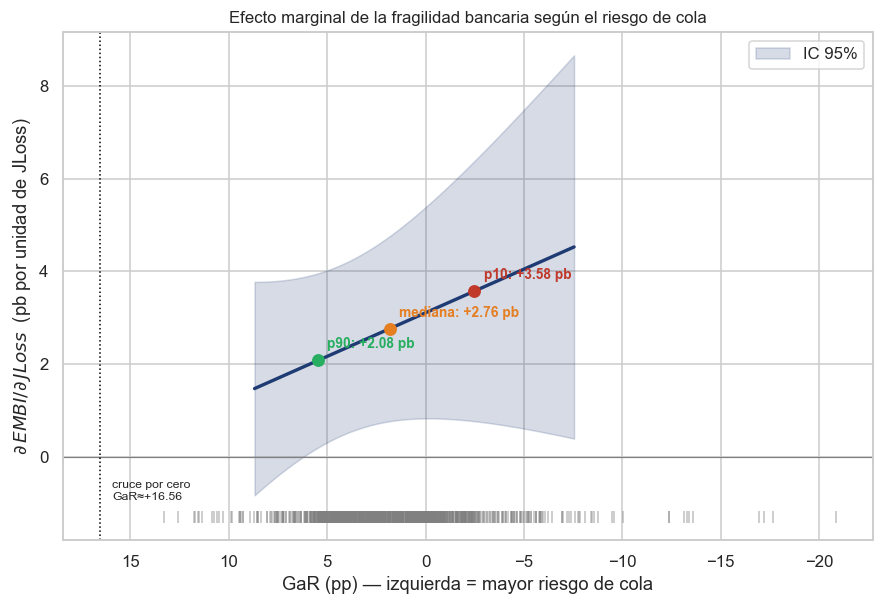

In [26]:
bJ, bI = b1, th
vJ, vI, cJI = V.loc['JLoss_c','JLoss_c'], V.loc['JxG_c','JxG_c'], V.loc['JLoss_c','JxG_c']
grid_g = np.linspace(P['GaR_pp'].quantile(.02), P['GaR_pp'].quantile(.98), 200)
dev = grid_g - mu_g; me = bJ + bI*dev; se = np.sqrt(vJ + dev**2*vI + 2*dev*cJI)
lo, hi = me-1.96*se, me+1.96*se
cross = mu_g - bJ/bI if bI != 0 else np.nan
fig, ax = plt.subplots(figsize=(9.5,6)); ax.axhline(0, color='grey', lw=.8)
ax.fill_between(grid_g, lo, hi, alpha=.18, color='#1f3b73', label='IC 95%'); ax.plot(grid_g, me, color='#1f3b73', lw=2.2)
for qq,lab,col in [(.10,'p10','#c0392b'),(.50,'mediana','#e67e22'),(.90,'p90','#27ae60')]:
    g = P['GaR_pp'].quantile(qq); e = bJ + bI*(g-mu_g)
    ax.scatter([g],[e], color=col, zorder=5, s=55)
    ax.annotate(f'{lab}: {e:+.2f} pb', (g,e), textcoords='offset points', xytext=(6,8), fontsize=9, color=col, fontweight='bold')
if np.isfinite(cross):
    ax.axvline(cross, color='black', ls=':', lw=1)
    ax.annotate(f'cruce por cero\nGaR≈{cross:+.2f}', (cross,0), textcoords='offset points', xytext=(8,-28), fontsize=8)
ax.plot(P['GaR_pp'], np.full(len(P), ax.get_ylim()[0]), '|', color='grey', alpha=.5, ms=8)
ax.set_xlabel('GaR (pp) — izquierda = mayor riesgo de cola')
ax.set_ylabel(r'$\partial\,EMBI/\partial\,JLoss$  (pb por unidad de JLoss)')
ax.set_title('Efecto marginal de la fragilidad bancaria según el riesgo de cola')
ax.invert_xaxis(); ax.legend(loc='upper right'); savefig('14_efecto_marginal'); plt.show()

## 14.2 Superficie de complementariedad

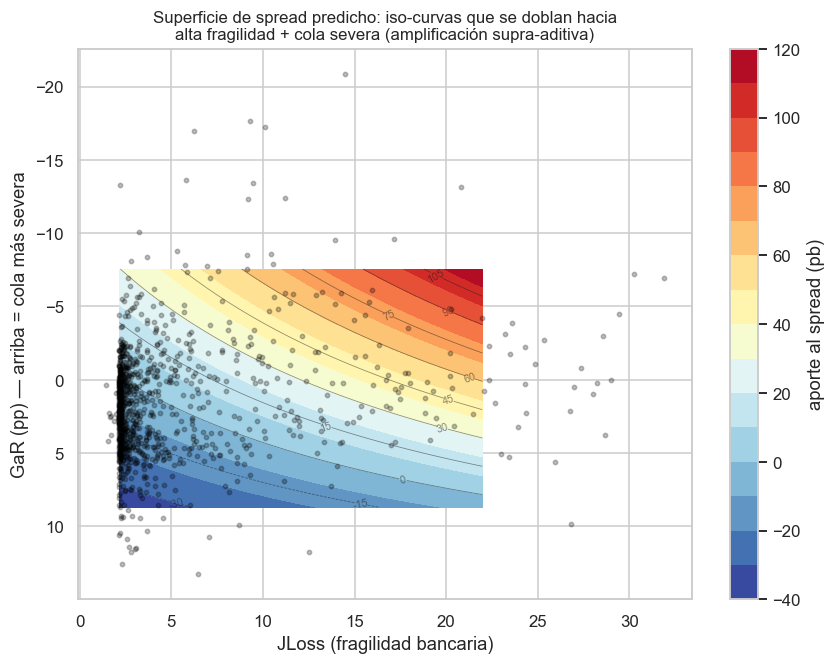

In [27]:
jg = np.linspace(P['JLoss'].quantile(.02), P['JLoss'].quantile(.98), 120)
gg = np.linspace(P['GaR_pp'].quantile(.02), P['GaR_pp'].quantile(.98), 120)
JJ, GG = np.meshgrid(jg, gg)
S = b1*(JJ-mu_J) + b2*(GG-mu_g) + th*((JJ-mu_J)*(GG-mu_g))
fig, ax = plt.subplots(figsize=(9,6.5))
cf = ax.contourf(JJ, GG, S, levels=18, cmap='RdYlBu_r')
cs = ax.contour(JJ, GG, S, levels=10, colors='k', linewidths=.5, alpha=.5); ax.clabel(cs, inline=True, fontsize=7, fmt='%.0f')
ax.scatter(P['JLoss'], P['GaR_pp'], s=8, color='black', alpha=.25); ax.invert_yaxis()
ax.set_xlabel('JLoss (fragilidad bancaria)'); ax.set_ylabel('GaR (pp) — arriba = cola más severa')
ax.set_title('Superficie de spread predicho: iso-curvas que se doblan hacia\nalta fragilidad + cola severa (amplificación supra-aditiva)')
fig.colorbar(cf, ax=ax, label='aporte al spread (pb)'); savefig('14_superficie_complementariedad'); plt.show()

## 14.3 Binscatter de EMBI vs JLoss por régimen de GaR

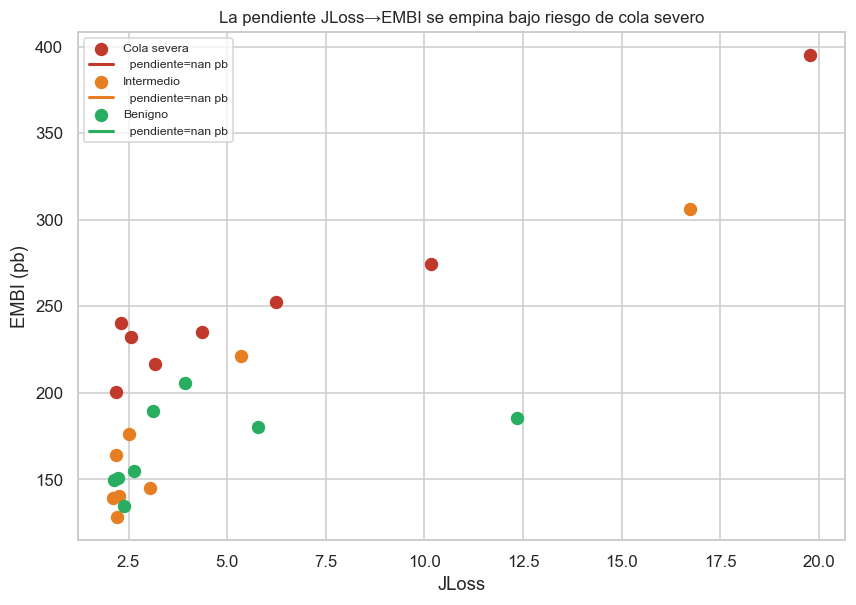

In [28]:
dd = P.copy(); dd['terc'] = pd.qcut(dd['GaR_pp'], 3, labels=['Cola severa','Intermedio','Benigno'])
palette = {'Cola severa':'#c0392b','Intermedio':'#e67e22','Benigno':'#27ae60'}
fig, ax = plt.subplots(figsize=(9,6))
for terc, g in dd.groupby('terc', observed=True):
    g = g.copy(); nb = min(8, g['JLoss'].nunique())
    if nb < 2: continue
    g['bin'] = pd.qcut(g['JLoss'].rank(method='first'), nb, labels=False)
    bs = g.groupby('bin').agg(J=('JLoss','mean'), E=('EMBI_bps','mean'))
    ax.scatter(bs['J'], bs['E'], color=palette[terc], s=60, zorder=4, label=terc)
    bcoef = np.polyfit(g['JLoss'], g['EMBI_bps'], 1)
    xs = np.linspace(g['JLoss'].min(), g['JLoss'].quantile(.97), 50)
    ax.plot(xs, np.polyval(bcoef, xs), color=palette[terc], lw=2, label=f'  pendiente={bcoef[0]:.1f} pb')
ax.set_xlabel('JLoss'); ax.set_ylabel('EMBI (pb)')
ax.set_title('La pendiente JLoss→EMBI se empina bajo riesgo de cola severo'); ax.legend(fontsize=8)
savefig('14_binscatter_regimen'); plt.show()

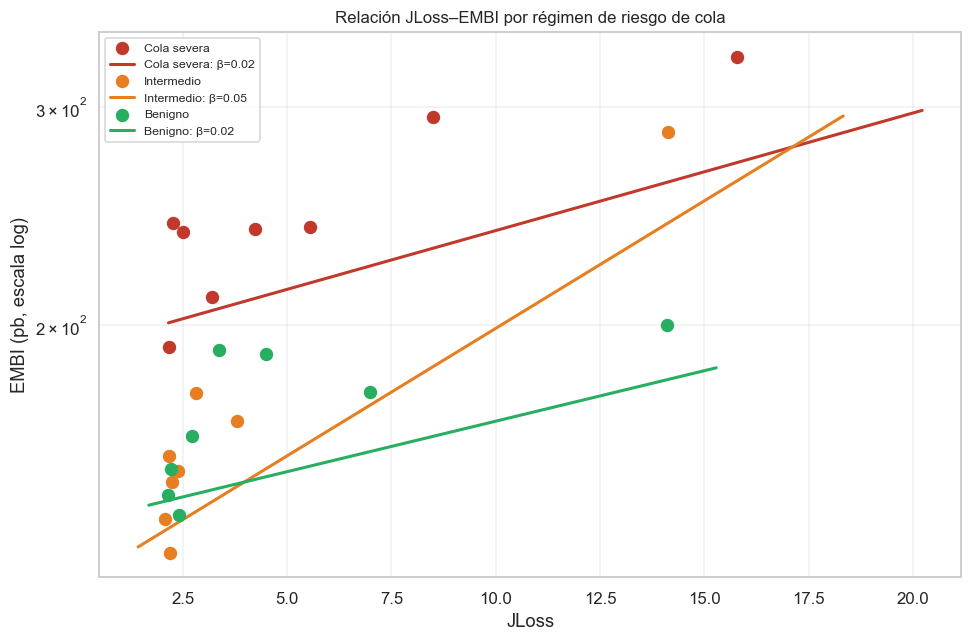

In [29]:
dd = P.copy()

dd['terc'] = pd.qcut(
    dd['GaR_pp'],
    3,
    labels=['Cola severa', 'Intermedio', 'Benigno']
)

palette = {
    'Cola severa': '#c0392b',
    'Intermedio': '#e67e22',
    'Benigno': '#27ae60'
}

fig, ax = plt.subplots(figsize=(9, 6))

for terc, g in dd.groupby('terc', observed=True):

    g = g.copy()

    # Eliminar valores no válidos para escala log
    g = g[(g['EMBI_bps'] > 0) & g['JLoss'].notna()]

    nb = min(8, g['JLoss'].nunique())
    if nb < 2:
        continue

    g['bin'] = pd.qcut(
        g['JLoss'].rank(method='first'),
        nb,
        labels=False
    )

    bs = g.groupby('bin').agg(
        J=('JLoss', 'mean'),
        E=('EMBI_bps', 'mean')
    )

    # Binscatter
    ax.scatter(
        bs['J'],
        bs['E'],
        color=palette[terc],
        s=60,
        zorder=4,
        label=terc
    )

    # Regresión log(EMBI) ~ JLoss
    bcoef = np.polyfit(
        g['JLoss'],
        np.log(g['EMBI_bps']),
        1
    )

    xs = np.linspace(
        g['JLoss'].min(),
        g['JLoss'].quantile(0.97),
        100
    )

    ys = np.exp(np.polyval(bcoef, xs))

    ax.plot(
        xs,
        ys,
        color=palette[terc],
        lw=2,
        label=f'{terc}: β={bcoef[0]:.2f}'
    )

# Escala logarítmica en Y
ax.set_yscale('log')

ax.set_xlabel('JLoss')
ax.set_ylabel('EMBI (pb, escala log)')
ax.set_title('Relación JLoss–EMBI por régimen de riesgo de cola')

ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()

savefig('14_binscatter_regimen_log')
plt.show()

## 14.4 *Forest plot* de θ: robustez en una imagen

Coeficiente de interacción y su IC95% a través de especificaciones y robustez (reestimadas con SE Driscoll-Kraay). Las filas se adaptan a las variables disponibles en la base.

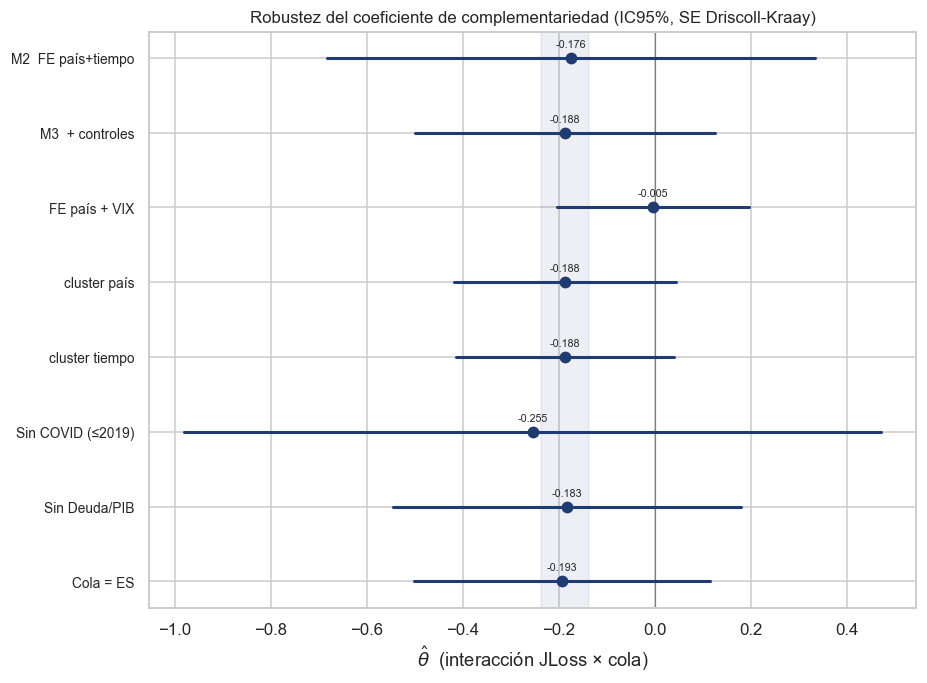

In [30]:
rows = []
def addrow(lbl, m, key='JxG_c'):
    if m is None or key not in m.params.index: return
    rows.append((lbl, m.params[key], m.std_errors[key]))
addrow('M2  FE país+tiempo', m2)
if FC: addrow('M3  + controles', ref)
if VIXVAR: addrow(f'FE país + {VIXVAR}', feols(wc_(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + {VIXVAR} + EntityEffects')))
if HAS_XG:
    sub_xg = P.dropna(subset=['X_global_idx']).set_index(['country','t'])
    addrow('+ X_global_idx (FE país)', feols('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + X_global_idx + EntityEffects', data=sub_xg))
addrow('cluster país',  PanelOLS.from_formula(wc_('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects'), Pi).fit(cov_type='clustered', cluster_entity=True))
addrow('cluster tiempo',PanelOLS.from_formula(wc_('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects'), Pi).fit(cov_type='clustered', cluster_time=True))
sub_nc = P[P['year'] < 2020].set_index(['country','t'])
addrow('Sin COVID (≤2019)', PanelOLS.from_formula(wc_('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects'), sub_nc).fit(**DK))
if 'debt_gdp' in CTRLS:
    FCnd = ' + '.join([c for c in CTRLS if c != 'debt_gdp'])
    addrow('Sin Deuda/PIB', feols(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + {FCnd} + EntityEffects + TimeEffects'))
if 'JxES_c' in P.columns:
    addrow('Cola = ES', feols(wc_('EMBI_bps ~ JLoss_c + ES_pp_c + JxES_c + EntityEffects + TimeEffects')), key='JxES_c')

fig, ax = plt.subplots(figsize=(9, 0.6*len(rows)+2)); ax.axvline(0, color='grey', lw=.8)
th_ref = th; ax.axvspan(th_ref-0.05, th_ref+0.05, color='#1f3b73', alpha=.08)
for i,(lbl,est,se) in enumerate(rows):
    ax.plot([est-1.96*se, est+1.96*se],[i,i], color='#1f3b73', lw=2)
    ax.scatter([est],[i], color='#1f3b73', zorder=5, s=45)
    ax.annotate(f'{est:+.3f}', (est,i), textcoords='offset points', xytext=(0,7), ha='center', fontsize=7)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xlabel(r'$\hat\theta$  (interacción JLoss × cola)')
ax.set_title('Robustez del coeficiente de complementariedad (IC95%, SE Driscoll-Kraay)'); ax.invert_yaxis()
savefig('14_forest_theta'); plt.show()

## 14.5 Modelo de umbral de Hansen

Modelo de umbral con efectos fijos (Hansen 1999/2000): el efecto de `JLoss` cambia de régimen según un umbral γ del GaR. Izq.: perfil LR(γ) con IC95% (LR≤7.35). Der.: efecto de `JLoss` por régimen. Control extra: `reer` si existe, si no `X_global_idx`.

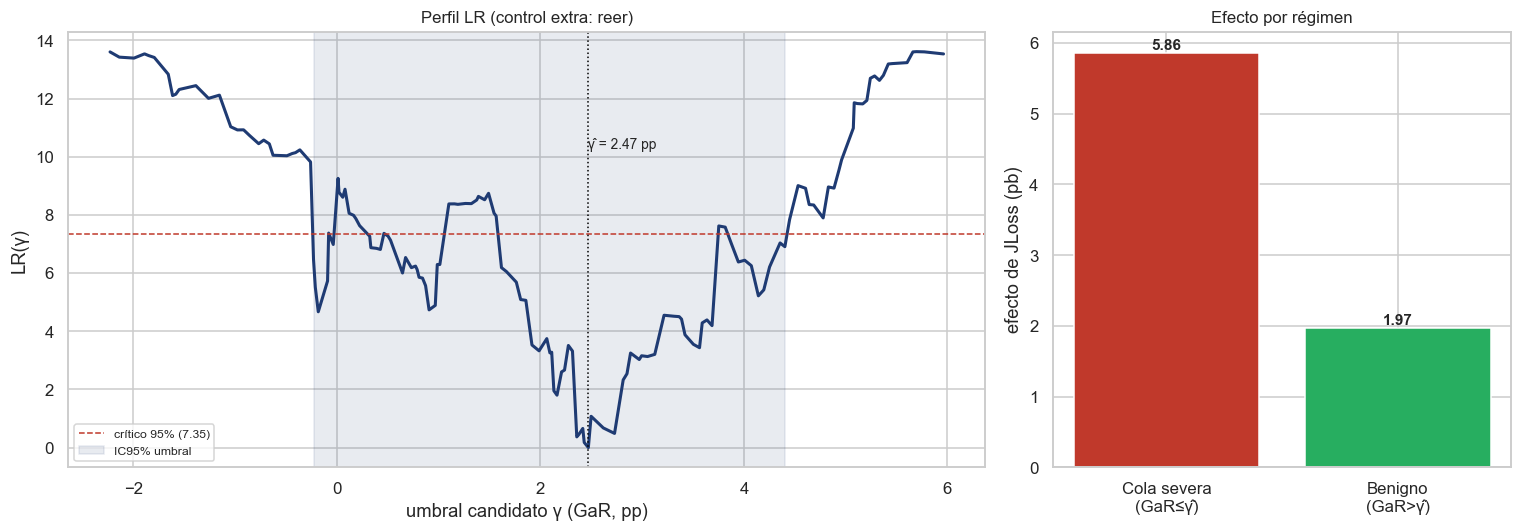

Umbral γ̂ = 2.471 pp (IC95%: [-0.23,4.40]) | JLoss severo=5.863 benigno=1.973


In [31]:
EXTRA = 'reer' if 'reer' in P.columns else ('X_global_idx' if HAS_XG else None)
cols_need = ['EMBI_bps','JLoss','GaR_pp'] + ([EXTRA] if EXTRA else [])
H = P.dropna(subset=cols_need).copy()
gc = H['country']
def wcx(s): return (s - s.groupby(gc.values).transform('mean')).values
yw = wcx(H['EMBI_bps']); Jw = wcx(H['JLoss']); Gw = wcx(H['GaR_pp'])
Xw = wcx(H[EXTRA]) if EXTRA else None
q = H['GaR_pp'].values; n = len(yw)
def ssr_beta(gam):
    dlo = (q <= gam).astype(float)
    cols = [Jw*dlo, Jw*(1-dlo), Gw] + ([Xw] if EXTRA else [])
    X = np.column_stack(cols); beta, *_ = np.linalg.lstsq(X, yw, rcond=None)
    e = yw - X@beta; return float(e@e), beta
grid_h = np.quantile(q, np.linspace(.10,.90,150)); res = [ssr_beta(gm) for gm in grid_h]
ssrs = np.array([r[0] for r in res]); ihat = ssrs.argmin(); gam_hat = grid_h[ihat]; ssr_min = ssrs[ihat]
LR = (ssrs - ssr_min)/(ssr_min/n); crit = 7.35
inside = grid_h[LR <= crit]; ci_lo, ci_hi = inside.min(), inside.max()
beta_lo, beta_hi = res[ihat][1][0], res[ihat][1][1]
fig, axes = plt.subplots(1,2, figsize=(14,5), gridspec_kw={'width_ratios':[2,1]})
axes[0].plot(grid_h, LR, color='#1f3b73', lw=2)
axes[0].axhline(crit, color='#c0392b', ls='--', lw=1, label='crítico 95% (7.35)')
axes[0].axvline(gam_hat, color='black', ls=':', lw=1); axes[0].axvspan(ci_lo, ci_hi, color='#1f3b73', alpha=.10, label='IC95% umbral')
axes[0].annotate(f'γ̂ = {gam_hat:.2f} pp', (gam_hat, crit*1.4), fontsize=9)
axes[0].set_xlabel('umbral candidato γ (GaR, pp)'); axes[0].set_ylabel('LR(γ)')
axes[0].set_title(f'Perfil LR (control extra: {EXTRA})'); axes[0].legend(fontsize=8)
axes[1].bar(['Cola severa\n(GaR≤γ̂)','Benigno\n(GaR>γ̂)'], [beta_lo, beta_hi], color=['#c0392b','#27ae60'])
axes[1].axhline(0, color='grey', lw=.6)
for i,v in enumerate([beta_lo,beta_hi]): axes[1].annotate(f'{v:.2f}', (i,v), ha='center', va='bottom' if v>=0 else 'top', fontsize=10, fontweight='bold')
axes[1].set_ylabel('efecto de JLoss (pb)'); axes[1].set_title('Efecto por régimen')
plt.tight_layout(); savefig('14_umbral_hansen'); plt.show()
print(f'Umbral γ̂ = {gam_hat:.3f} pp (IC95%: [{ci_lo:.2f},{ci_hi:.2f}]) | JLoss severo={beta_lo:.3f} benigno={beta_hi:.3f}')

## 14.6 Series de tiempo por país: JLoss, GaR y EMBI

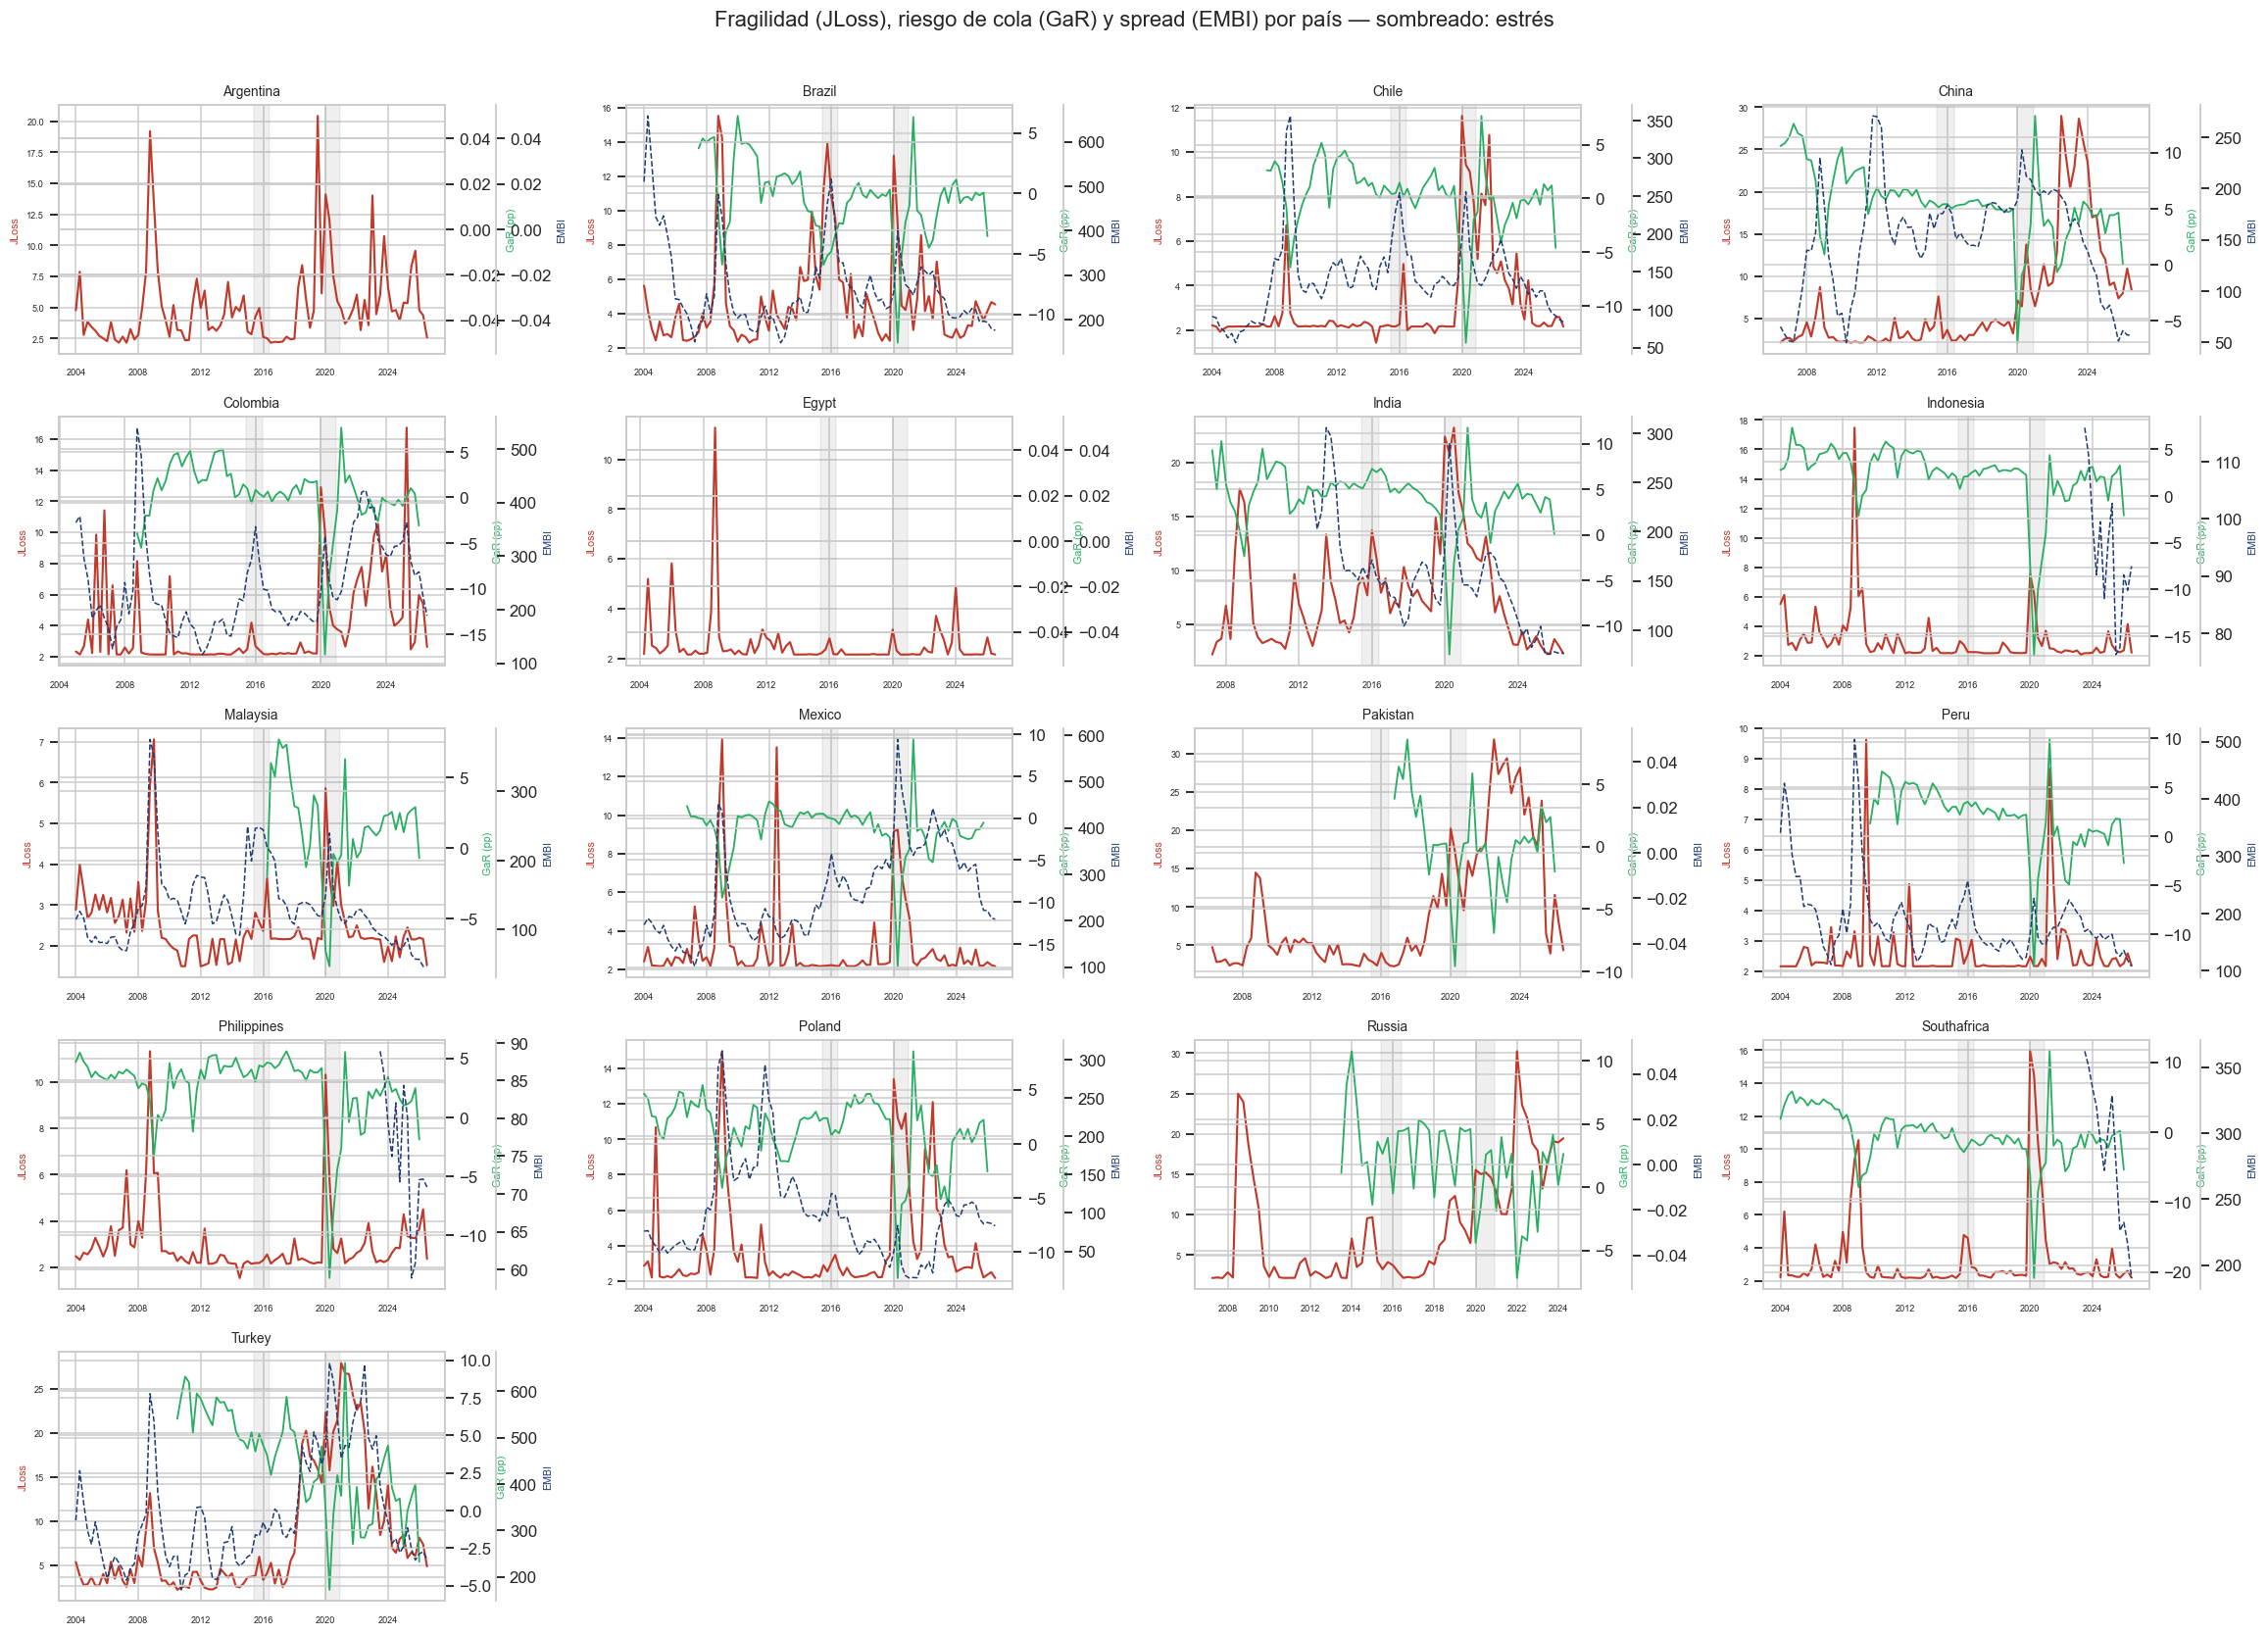

In [32]:
countries = sorted(P['country'].unique()); n = len(countries); nr, nc = grid(n)
fig, axes = plt.subplots(nr, nc, figsize=(5.3*nc, 3*nr)); axes = np.atleast_1d(axes).ravel()
for i,c in enumerate(countries):
    gg = P[P.country==c].sort_values('date'); ax = axes[i]
    ax.plot(gg['date'], gg['JLoss'], color='#c0392b', lw=1.4); ax.set_ylabel('JLoss', color='#c0392b', fontsize=7)
    a2 = ax.twinx(); a2.plot(gg['date'], gg['GaR_pp'], color='#27ae60', lw=1.2); a2.set_ylabel('GaR (pp)', color='#27ae60', fontsize=7)
    a3 = ax.twinx(); a3.spines['right'].set_position(('outward',34))
    a3.plot(gg['date'], gg['EMBI_bps'], color='#1f3b73', lw=1.0, ls='--'); a3.set_ylabel('EMBI', color='#1f3b73', fontsize=7)
    for (s,e) in [('2015-06','2016-06'),('2020-01','2020-12')]: ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color='grey', alpha=.12)
    ax.set_title(c.capitalize(), fontsize=9); ax.tick_params(labelsize=6)
for j in range(n, len(axes)): axes[j].axis('off')
fig.suptitle('Fragilidad (JLoss), riesgo de cola (GaR) y spread (EMBI) por país — sombreado: estrés', y=1.01)
plt.tight_layout(); savefig('14_series_pais'); plt.show()

## 14.7 Contabilidad del spread en un episodio

Descomposición del cambio predicho del spread en aportes de JLoss, GaR e interacción para el shock COVID (2019Q4→2020Q2), en el país con dato para ese episodio.

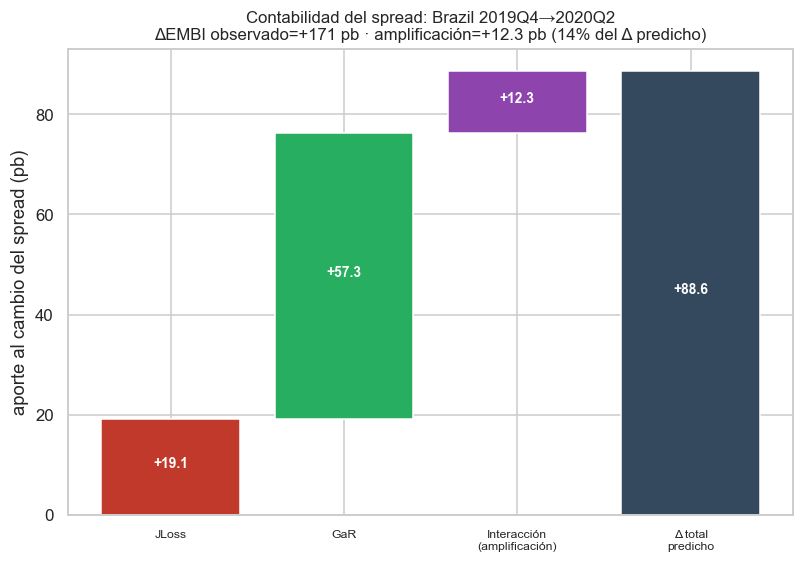

In [33]:
def pick_episode(P):
    for c in ['brazil','mexico','colombia','chile','peru'] + sorted(P['country'].unique()):
        hv = set(P.loc[P.country==c,'quarter'])
        if {'2019Q4','2020Q2'} <= hv: return c,'2019Q4','2020Q2'
    P2 = P.sort_values(['country','t']).copy(); P2['dE'] = P2.groupby('country')['EMBI_bps'].diff()
    r = P2.loc[P2['dE'].idxmax()]; prev = P2[(P2.country==r['country'])].iloc[max(0, list(P2[P2.country==r['country']].quarter).index(r['quarter'])-1)]
    return r['country'], prev['quarter'], r['quarter']
country, q0, q1 = pick_episode(P)
a = P[(P.country==country)&(P.quarter==q0)].iloc[0]; b = P[(P.country==country)&(P.quarter==q1)].iloc[0]
dJ = b['JLoss_c']-a['JLoss_c']; dG = b['GaR_pp_c']-a['GaR_pp_c']
dInt = b['JLoss_c']*b['GaR_pp_c'] - a['JLoss_c']*a['GaR_pp_c']
comp = {'JLoss': b1*dJ, 'GaR': b2*dG, 'Interacción\n(amplificación)': th*dInt}
dEMBI_obs = b['EMBI_bps']-a['EMBI_bps']
fig, ax = plt.subplots(figsize=(8.5,5.5)); labels=list(comp); vals=list(comp.values())
cum=np.cumsum([0]+vals[:-1]); colors=['#c0392b','#27ae60','#8e44ad']
for i,(l,v) in enumerate(zip(labels,vals)):
    ax.bar(i, v, bottom=cum[i], color=colors[i]); ax.annotate(f'{v:+.1f}', (i, cum[i]+v/2), ha='center', fontsize=9, fontweight='bold', color='white')
ax.bar(len(labels), sum(vals), color='#34495e'); ax.annotate(f'{sum(vals):+.1f}', (len(labels), sum(vals)/2), ha='center', fontsize=9, fontweight='bold', color='white')
ax.set_xticks(range(len(labels)+1)); ax.set_xticklabels(labels+['Δ total\npredicho'], fontsize=8); ax.axhline(0, color='grey', lw=.6)
ax.set_ylabel('aporte al cambio del spread (pb)')
share = th*dInt
ax.set_title(f'Contabilidad del spread: {country.capitalize()} {q0}→{q1}\n'
             f'ΔEMBI observado={dEMBI_obs:+.0f} pb · amplificación={share:+.1f} pb ({share/sum(vals)*100:.0f}% del Δ predicho)')
savefig('14_contabilidad_episodio'); plt.show()

## 14.8 Contrafactual "sin *doom loop*" (θ = 0)

Prima de amplificación por la complementariedad: θ·(JLoss_c × GaR_c), por país en el tiempo.

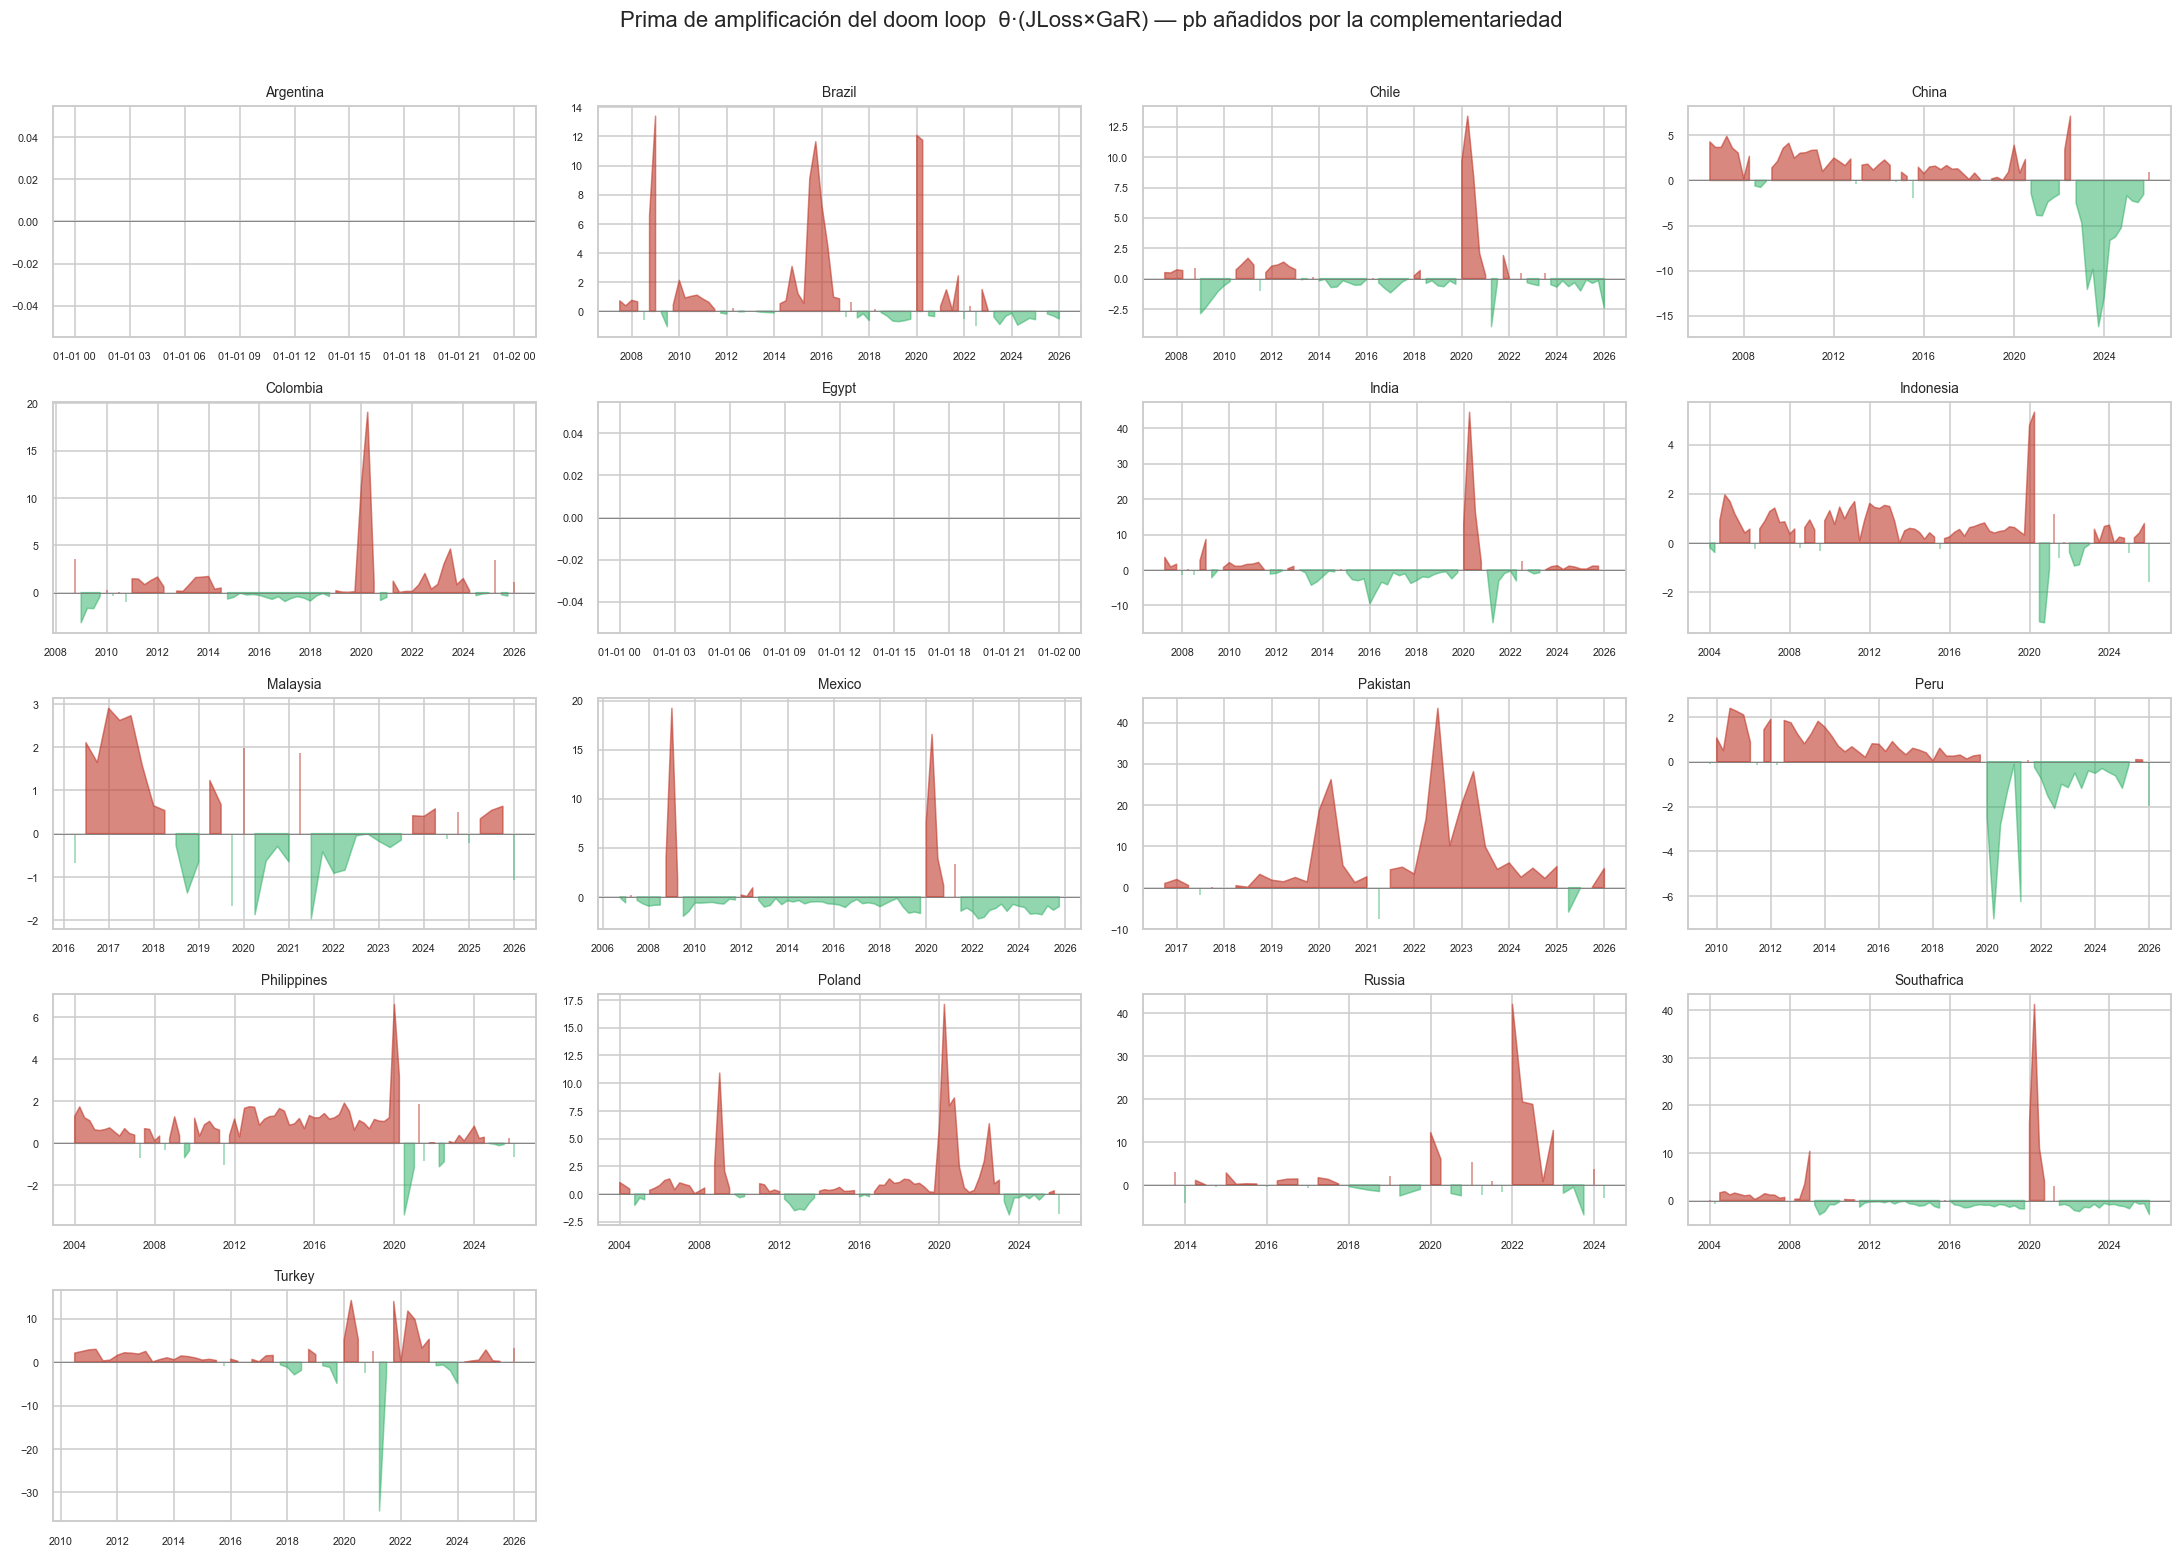

Prima media donde es positiva: 2.33 pb · máx 44.6 pb


In [34]:
P['amp_premium'] = th * P['JLoss_c'] * P['GaR_pp_c']
countries = sorted(P['country'].unique()); n = len(countries); nr, nc = grid(n)
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 2.8*nr)); axes = np.atleast_1d(axes).ravel()
for i,c in enumerate(countries):
    gg = P[P.country==c].sort_values('date'); ax = axes[i]
    ax.fill_between(gg['date'], 0, gg['amp_premium'], where=gg['amp_premium']>=0, color='#c0392b', alpha=.6)
    ax.fill_between(gg['date'], 0, gg['amp_premium'], where=gg['amp_premium']<0, color='#27ae60', alpha=.5)
    ax.axhline(0, color='grey', lw=.6); ax.set_title(c.capitalize(), fontsize=9); ax.tick_params(labelsize=7)
for j in range(n, len(axes)): axes[j].axis('off')
fig.suptitle('Prima de amplificación del doom loop  θ·(JLoss×GaR) — pb añadidos por la complementariedad', y=1.01)
plt.tight_layout(); savefig('14_contrafactual'); plt.show()
print(f"Prima media donde es positiva: {P.loc[P['amp_premium']>0,'amp_premium'].mean():.2f} pb · máx {P['amp_premium'].max():.1f} pb")

## 14.9 Heterogeneidad *leave-one-country-out*

Se reestima θ (M2, FE bidireccional) excluyendo cada país, para descartar que uno solo arrastre el resultado.

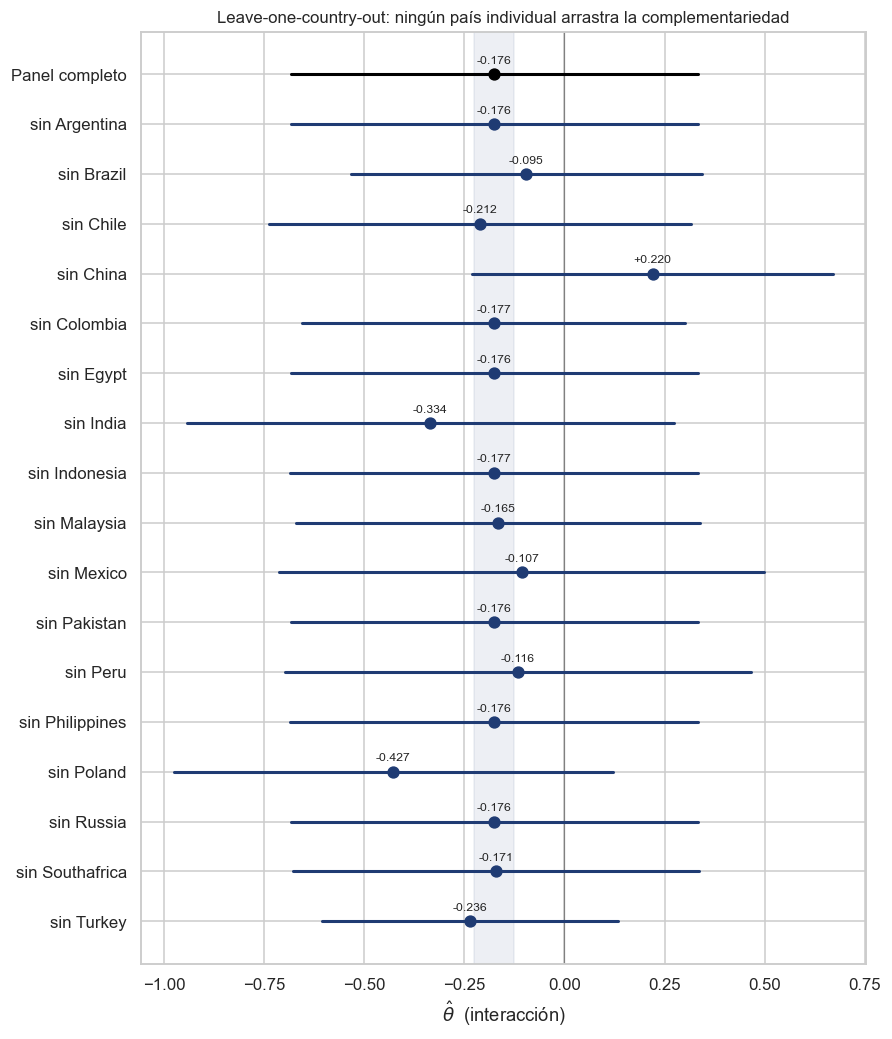

In [35]:
rows=[]
full = feols('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects')
rows.append(('Panel completo', full.params['JxG_c'], full.std_errors['JxG_c']))
for c in sorted(P['country'].unique()):
    sub = P[P.country!=c].set_index(['country','t'])
    try:
        r = PanelOLS.from_formula('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects', sub).fit(**DK)
        rows.append((f'sin {c.capitalize()}', r.params['JxG_c'], r.std_errors['JxG_c']))
    except Exception: pass
fig, ax = plt.subplots(figsize=(8.5, 0.5*len(rows)+2)); ax.axvline(0, color='grey', lw=.8)
ax.axvspan(full.params['JxG_c']-0.05, full.params['JxG_c']+0.05, color='#1f3b73', alpha=.08)
for i,(lbl,est,se) in enumerate(rows):
    col = 'black' if lbl=='Panel completo' else '#1f3b73'
    ax.plot([est-1.96*se, est+1.96*se],[i,i], color=col, lw=2); ax.scatter([est],[i], color=col, s=50, zorder=5)
    ax.annotate(f'{est:+.3f}', (est,i), textcoords='offset points', xytext=(0,7), ha='center', fontsize=8)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows]); ax.invert_yaxis()
ax.set_xlabel(r'$\hat\theta$  (interacción)')
ax.set_title('Leave-one-country-out: ningún país individual arrastra la complementariedad')
savefig('14_leave_one_out'); plt.show()

## Cierre — archivos exportados

In [36]:
print('Tablas:'); [print('  ', f) for f in sorted(os.listdir(OUTDIR)) if f.endswith(('.csv','.tex'))]
print('Figuras:'); [print('  ', f) for f in sorted(os.listdir(FIGDIR))]
print('\nEDA completo (secciones 1-14). Todo guardado en', OUTDIR.resolve())

Tablas:
   cobertura_por_pais.csv
   descomposicion_within_between.csv
   matriz_correlaciones.csv
   medias_por_regimen_VIX.csv
   tabla_descriptiva_global.csv
   tabla_descriptiva_global.tex
   tabla_descriptiva_por_pais.csv
Figuras:
   04_distribuciones.png
   04b_boxplots_pais.png
   05_comovimiento.png
   05_ts_embi.png
   05_ts_gar.png
   05_ts_jloss.png
   06_complementariedad.png
   06_scatter_embi.png
   07_correlaciones.png
   09_persistencia.png
   13_anchura_colas.png
   13_cola_izquierda.png
   13_curva_gar.png
   13_volatilidad_gar.png
   14_binscatter_regimen.png
   14_binscatter_regimen_log.png
   14_contabilidad_episodio.png
   14_contrafactual.png
   14_efecto_marginal.png
   14_forest_theta.png
   14_leave_one_out.png
   14_series_pais.png
   14_superficie_complementariedad.png
   14_umbral_hansen.png

EDA completo (secciones 1-14). Todo guardado en C:\Users\HOME\Claude\proyects\Jloss\1_Codigo\Panel\eda_output_bbg
